<a href="https://colab.research.google.com/github/axrodriguez5072019/s100-tareas/blob/main/Proyecto_Maestria_Pronostico_Poblacion_Penitenciaria.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Proyecto de Maestría — Pronóstico de Población Penitenciaria de Panamá

**Tema propuesto:**  
**Modelos estadísticos y de aprendizaje automático para el pronóstico a 30 días de la población penitenciaria por centro, Panamá 2024–2026.**

## Diseño analítico

El proyecto se divide en cuatro bloques:

1. **Calidad y preparación de datos**
2. **Análisis descriptivo temporal:** día, mes, trimestre y año
3. **Contraste de hipótesis**
4. **Pronóstico y comparación de modelos:** media móvil, regresión, SARIMA/SARIMAX y XGBoost

### Variable objetivo

\[
Y_{t+30}=\text{Población penitenciaria del mismo centro 30 días después}
\]

El horizonte de 30 días permite conservar la riqueza de la serie diaria y producir un resultado útil para planificación mensual.

### Hipótesis principales

**Hipótesis general**

- \(H_0\): Las características temporales, operativas y penitenciarias no explican significativamente la población penitenciaria futura.
- \(H_1\): Las características temporales, operativas y penitenciarias explican significativamente la población penitenciaria futura.

**Tendencia**

- \(H_0:\beta_{tendencia}=0\)
- \(H_1:\beta_{tendencia}\neq0\)

**Ingresos**

- \(H_0:\beta_{ingresos}=0\)
- \(H_1:\beta_{ingresos}\neq0\)

**Egresos**

- \(H_0:\beta_{egresos}=0\)
- \(H_1:\beta_{egresos}\neq0\)

> Importante: `Saldo = Ingreso - Egreso`. No deben incluirse simultáneamente `Ingreso`, `Egreso` y `Saldo` en la misma regresión porque el saldo es combinación lineal exacta de las otras dos variables.

> **Depuración específica aplicada:** se excluyen completamente del análisis las fechas **28, 29 y 30 de enero de 2026**, debido a que presentan cargas parciales de centros y generan descensos artificiales en la población agregada.
> **Visualización actualizada:** los boxplots mensuales comparan los años dentro de una misma figura, con el orden 2024–2025–2026 por cada mes.



## 1. Instalar/importar librerías y cargar el archivo

En Google Colab, suba el archivo **Datos poblacion 2024-2026.xlsx** cuando se solicite.


In [1]:

# En Google Colab, si hace falta:
# !pip -q install xgboost openpyxl statsmodels

import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats
import statsmodels.formula.api as smf
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import het_breuschpagan, acorr_ljungbox
from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from xgboost import XGBRegressor

ARCHIVO = "Datos poblacion 2024-2026.xlsx"

if not os.path.exists(ARCHIVO):
    try:
        from google.colab import files
        uploaded = files.upload()
        ARCHIVO = next(iter(uploaded.keys()))
    except Exception:
        raise FileNotFoundError(
            "Coloque el archivo Excel en la misma carpeta del notebook "
            "o modifique la variable ARCHIVO."
        )

df = pd.read_excel(ARCHIVO)

print("Filas:", len(df))
print("Columnas:", df.shape[1])
display(df.head())


Filas: 18634
Columnas: 12


,Fecha,Provincia,Centro,Capacidad,Camas,PoblacionPenal,SobrePoblacion,IndiceHacinamiento,Ingreso,Egreso,NivelHacinamiento,Archivo
0,2024-01-01,Bocas Del Toro,Cárcel Pública De Deborah,292,292,712,420.0,243.835616,1,0.0,Crítico,ESTADO DE FUERZA Y POBLACIO 01 de Enero 2024...
1,2024-01-01,Chiriquí,Centro Penitenciario De Chiriquí,950,950,2208,1258.0,232.421053,0,0.0,Crítico,ESTADO DE FUERZA Y POBLACIO 01 de Enero 2024...
2,2024-01-01,Chiriquí,Centro Femenino Los Algarrobos,80,188,193,113.0,102.659574,0,0.0,Crítico,ESTADO DE FUERZA Y POBLACIO 01 de Enero 2024...
3,2024-01-01,Veraguas,Cárcel Púiblica De Santiago,150,29,713,563.0,2458.620690,0,0.0,Crítico,ESTADO DE FUERZA Y POBLACIO 01 de Enero 2024...
4,2024-01-01,Los Santos,Cárcel Pública De Las Tablas,75,133,357,282.0,268.421053,0,0.0,Crítico,ESTADO DE FUERZA Y POBLACIO 01 de Enero 2024...


## 2. Auditoría inicial y exclusión de fechas incompletas

Antes de construir indicadores y modelos se aplica una regla de depuración específica: se eliminan de **todo el análisis** los registros correspondientes a **28/01/2026, 29/01/2026 y 30/01/2026**, ya que esas fechas contienen cargas parciales de centros y producen descensos artificiales al agregar la población del sistema.

La auditoría que se imprime a continuación corresponde a la base **después de esta exclusión**. La base original se conserva sin modificaciones en el archivo Excel fuente.

In [2]:

df["Fecha"] = pd.to_datetime(df["Fecha"], errors="coerce")

# EXCLUSIÓN SOLICITADA: fechas con carga parcial de centros
fechas_excluir = pd.to_datetime(["2026-01-28", "2026-01-29", "2026-01-30"])
registros_excluidos = df[df["Fecha"].isin(fechas_excluir)].copy()
print("Registros excluidos por fechas incompletas:", len(registros_excluidos))
print(registros_excluidos.groupby("Fecha")["Centro"].nunique().rename("Centros_reportados"))
df = df[~df["Fecha"].isin(fechas_excluir)].copy().reset_index(drop=True)
print("Filas después de excluir 28, 29 y 30 de enero de 2026:", len(df))


print("Rango temporal:", df["Fecha"].min(), "a", df["Fecha"].max())
print("Fechas distintas:", df["Fecha"].nunique())
print("Provincias:", df["Provincia"].nunique())
print("Centros originales:", df["Centro"].nunique())

auditoria = pd.DataFrame({
    "Variable": df.columns,
    "Faltantes": [df[c].isna().sum() for c in df.columns],
    "Porcentaje_faltante": [df[c].isna().mean()*100 for c in df.columns],
    "Valores_unicos": [df[c].nunique(dropna=True) for c in df.columns]
})
display(auditoria)

duplicados = df[df.duplicated(["Fecha", "Centro"], keep=False)].sort_values(["Fecha", "Centro"])
print("Registros involucrados en duplicidades Fecha-Centro:", len(duplicados))
display(duplicados.head(20))

print("\nFrecuencia de NivelHacinamiento:")
display(df["NivelHacinamiento"].value_counts(dropna=False).to_frame("n"))


Registros excluidos por fechas incompletas: 42
Fecha
2026-01-28    13
2026-01-29    14
2026-01-30    15
Name: Centros_reportados, dtype: int64
Filas después de excluir 28, 29 y 30 de enero de 2026: 18592
Rango temporal: 2024-01-01 00:00:00 a 2026-06-30 00:00:00
Fechas distintas: 905
Provincias: 9
Centros originales: 25


,Variable,Faltantes,Porcentaje_faltante,Valores_unicos
0,Fecha,0,0.000000,905
1,Provincia,0,0.000000,9
2,Centro,0,0.000000,25
3,Capacidad,0,0.000000,26
4,Camas,0,0.000000,33
5,PoblacionPenal,0,0.000000,1958
6,SobrePoblacion,2,0.010757,1857
7,IndiceHacinamiento,12,0.064544,2680
8,Ingreso,0,0.000000,60
9,Egreso,1,0.005379,79


Registros involucrados en duplicidades Fecha-Centro: 20


,Fecha,Provincia,Centro,Capacidad,Camas,PoblacionPenal,SobrePoblacion,IndiceHacinamiento,Ingreso,Egreso,NivelHacinamiento,Archivo
799,2024-02-10,Darién,Cárcel Pública De La Palma,18,18,23,5.0,127.777778,0,0.0,Crítico,ESTADO DE FUERZA Y POPLACION 09 FEBRERO.xlsx
818,2024-02-10,Darién,Cárcel Pública De La Palma,18,18,24,6.0,133.333333,1,0.0,Crítico,ESTADO DE FUERZA Y POPLACION 10 FEBRERO.xlsx
1939,2024-04-07,Bocas Del Toro,Cárcel Pública De Deborah,292,292,773,481.0,264.726027,1,0.0,Crítico,ESTADO DE FUERZA Y POPLACION 07 DE ABRIL 2024....
1958,2024-04-07,Bocas Del Toro,Cárcel Pública De Deborah,292,292,773,481.0,264.726027,0,0.0,Crítico,ESTADO DE FUERZA Y POPLACION 08 DE ABRIL 2024....
4870,2024-09-01,Bocas Del Toro,Cárcel Pública De Deborah,292,292,868,562.0,297.260274,0,0.0,Crítico,POBLACION Y ESTADO DE FUERZA 01 DE SEPTIEMBRE ...
4871,2024-09-01,Bocas Del Toro,Cárcel Pública De Deborah,292,292,868,562.0,297.260274,0,0.0,Crítico,POBLACION Y ESTADO DE FUERZA 01 DE SEPTIEMBRE ...
8580,2025-03-06,Darién,Cárcel Pública De La Palma,18,7,0,0.0,NaN,0,0.0,critico,POBLACION Y ESTADO DE FUERZA DE 05 MARZO 2025....
8600,2025-03-06,Darién,Cárcel Pública De La Palma,18,18,7,-11.0,38.888889,0,0.0,Crítico,POBLACION Y ESTADO DE FUERZA DE 06 MARZO 2025....
8663,2025-03-10,Darién,Cárcel Pública De La Palma,18,18,7,-11.0,38.888889,0,0.0,Crítico,POBLACION Y ESTADO DE FUERZA DE 10 MARZO 2025....
8683,2025-03-10,Darién,Cárcel Pública De La Palma,18,18,7,-11.0,38.888889,0,0.0,Crítico,POBLACION Y ESTADO DE FUERZA DE 10 MARZO 2025....



Frecuencia de NivelHacinamiento:


,n
NivelHacinamiento,
Crítico,18434
Sin hacinamiento,136
critico,22



## 3. Limpieza mínima y estandarización

Se corrigen únicamente equivalencias evidentes de escritura. No se fusionan centros diferentes sin validación institucional.

También se recalculan dos indicadores distintos:

\[
OcupacionCapacidad = rac{PoblacionPenal}{Capacidad}	imes100
\]

\[
OcupacionCamas = rac{PoblacionPenal}{Camas}	imes100
\]

Esto evita depender del `IndiceHacinamiento` original, cuya fórmula no es homogénea en todo el período.


In [3]:

alias_centros = {
    "Centro Femenino De Colon": "Centro Femenino De Colón",
    "Centro Femenino De Rehabilitacion La Esmelarda": "Centro Femenino La Esmeralda",
}

df["Centro_original"] = df["Centro"]
df["Centro"] = df["Centro"].replace(alias_centros)

# Mantener el último registro cuando existe más de una fila para la misma fecha-centro.
# Las duplicidades deben conservarse aparte como evidencia de calidad.
df = (
    df.sort_values(["Fecha", "Centro"])
      .drop_duplicates(["Fecha", "Centro"], keep="last")
      .reset_index(drop=True)
)

df["OcupacionCapacidad"] = np.where(
    df["Capacidad"].gt(0),
    df["PoblacionPenal"] / df["Capacidad"] * 100,
    np.nan
)

df["OcupacionCamas"] = np.where(
    df["Camas"].gt(0),
    df["PoblacionPenal"] / df["Camas"] * 100,
    np.nan
)

df["SobreCapacidadCalc"] = np.where(
    df["Capacidad"].notna(),
    df["PoblacionPenal"] - df["Capacidad"],
    np.nan
)

df["EstaSobreCapacidad"] = np.where(
    df["Capacidad"].gt(0),
    (df["PoblacionPenal"] > df["Capacidad"]).astype(int),
    np.nan
)

print("Filas después de deduplicar:", len(df))
print("Centros estandarizados:", df["Centro"].nunique())


Filas después de deduplicar: 18582
Centros estandarizados: 23



## 4. Variables analíticas temporales y operativas


In [4]:

df = df.sort_values(["Centro", "Fecha"]).reset_index(drop=True)

# Variables temporales
df["Año"] = df["Fecha"].dt.year
df["Mes"] = df["Fecha"].dt.month
df["NombreMes"] = df["Fecha"].dt.month_name()
df["Trimestre"] = df["Fecha"].dt.quarter
df["Semana"] = df["Fecha"].dt.isocalendar().week.astype(int)
df["DiaSemana"] = df["Fecha"].dt.dayofweek
df["DiaAño"] = df["Fecha"].dt.dayofyear
df["Tendencia"] = (df["Fecha"] - df["Fecha"].min()).dt.days

# Variables operativas
df["Saldo"] = df["Ingreso"] - df["Egreso"]

# Rezagos
for lag in [1, 7, 14, 30]:
    df[f"PoblacionLag{lag}"] = df.groupby("Centro")["PoblacionPenal"].shift(lag)

# Medias móviles basadas únicamente en información pasada
for ventana in [7, 14, 30]:
    df[f"MediaMovil{ventana}"] = (
        df.groupby("Centro")["PoblacionPenal"]
          .transform(lambda s: s.shift(1).rolling(ventana, min_periods=max(3, ventana//3)).mean())
    )

# Acumulados operativos recientes
for ventana in [7, 30]:
    df[f"Ingreso_{ventana}d"] = (
        df.groupby("Centro")["Ingreso"]
          .transform(lambda s: s.shift(1).rolling(ventana, min_periods=3).sum())
    )
    df[f"Egreso_{ventana}d"] = (
        df.groupby("Centro")["Egreso"]
          .transform(lambda s: s.shift(1).rolling(ventana, min_periods=3).sum())
    )
    df[f"Saldo_{ventana}d"] = df[f"Ingreso_{ventana}d"] - df[f"Egreso_{ventana}d"]

# Crecimiento reciente
df["Crecimiento7d"] = (
    (df["PoblacionPenal"] - df["PoblacionLag7"]) /
    df["PoblacionLag7"].replace(0, np.nan) * 100
)

display(df.head())


,Fecha,Provincia,Centro,Capacidad,Camas,PoblacionPenal,SobrePoblacion,IndiceHacinamiento,Ingreso,Egreso,...,MediaMovil7,MediaMovil14,MediaMovil30,Ingreso_7d,Egreso_7d,Saldo_7d,Ingreso_30d,Egreso_30d,Saldo_30d,Crecimiento7d
0,2024-01-01,Panamá,C.D.P. De Punta Coco,12,12,11,-1.0,91.666667,0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-01-02,Panamá,C.D.P. De Punta Coco,12,12,11,-1.0,91.666667,0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2024-01-03,Panamá,C.D.P. De Punta Coco,12,12,11,-1.0,91.666667,0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2024-01-04,Panamá,C.D.P. De Punta Coco,12,12,11,-1.0,91.666667,0,0.0,...,11.0,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,NaN
4,2024-01-05,Panamá,C.D.P. De Punta Coco,12,12,11,-1.0,91.666667,0,0.0,...,11.0,11.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,NaN



## 5. Crear la variable objetivo a 30 días

Se utiliza un **emparejamiento por fecha exacta** en vez de `shift(-30)`. Así, si falta un día en la serie, no se confunde "30 filas" con "30 días".


In [5]:

futuro = df[["Centro", "Fecha", "PoblacionPenal"]].copy()
futuro["Fecha"] = futuro["Fecha"] - pd.Timedelta(days=30)
futuro = futuro.rename(columns={"PoblacionPenal": "Poblacion_30d"})

df_modelo = df.merge(
    futuro,
    on=["Centro", "Fecha"],
    how="left"
)

df_modelo["FechaObjetivo"] = df_modelo["Fecha"] + pd.Timedelta(days=30)

print("Registros con objetivo a 30 días:", df_modelo["Poblacion_30d"].notna().sum())


Registros con objetivo a 30 días: 17746



# BLOQUE A — ANÁLISIS DESCRIPTIVO

Para población, capacidad y camas **no se deben sumar las observaciones diarias del mes**.  
La población es un **stock**: para el resumen mensual/anual se toma el último corte disponible del período.

Ingreso y egreso son **flujos**: estos sí se acumulan dentro del período.


In [6]:

# Último corte por centro y mes
corte_mensual = (
    df.sort_values("Fecha")
      .groupby(["Centro", "Año", "Mes"], as_index=False)
      .tail(1)
)

resumen_mensual_stock = (
    corte_mensual
    .groupby(["Año", "Mes"], as_index=False)
    .agg(
        Poblacion=("PoblacionPenal", "sum"),
        Capacidad=("Capacidad", "sum"),
        Camas=("Camas", "sum")
    )
)

flujos_mensuales = (
    df.groupby(["Año", "Mes"], as_index=False)
      .agg(Ingresos=("Ingreso", "sum"), Egresos=("Egreso", "sum"))
)

resumen_mensual = resumen_mensual_stock.merge(
    flujos_mensuales, on=["Año", "Mes"], how="left"
)

resumen_mensual["OcupacionCapacidad"] = (
    resumen_mensual["Poblacion"] / resumen_mensual["Capacidad"] * 100
)
resumen_mensual["Saldo"] = resumen_mensual["Ingresos"] - resumen_mensual["Egresos"]

display(resumen_mensual.tail(12))


,Año,Mes,Poblacion,Capacidad,Camas,Ingresos,Egresos,OcupacionCapacidad,Saldo
18,2025,7,24445,14700,14682,898,1196.0,166.292517,-298.0
19,2025,8,24512,14700,14682,903,837.0,166.748299,66.0
20,2025,9,24576,14700,14682,860,796.0,167.183673,64.0
21,2025,10,24587,14700,14682,933,926.0,167.258503,7.0
22,2025,11,24860,14700,14682,964,724.0,169.115646,240.0
23,2025,12,24924,14700,14682,992,928.0,169.551020,64.0
24,2026,1,24529,14700,14682,700,1099.0,166.863946,-399.0
25,2026,2,24651,14700,14682,667,540.0,167.693878,127.0
26,2026,3,24727,14700,14682,993,917.0,168.210884,76.0
27,2026,4,24831,14700,14682,845,763.0,168.918367,82.0


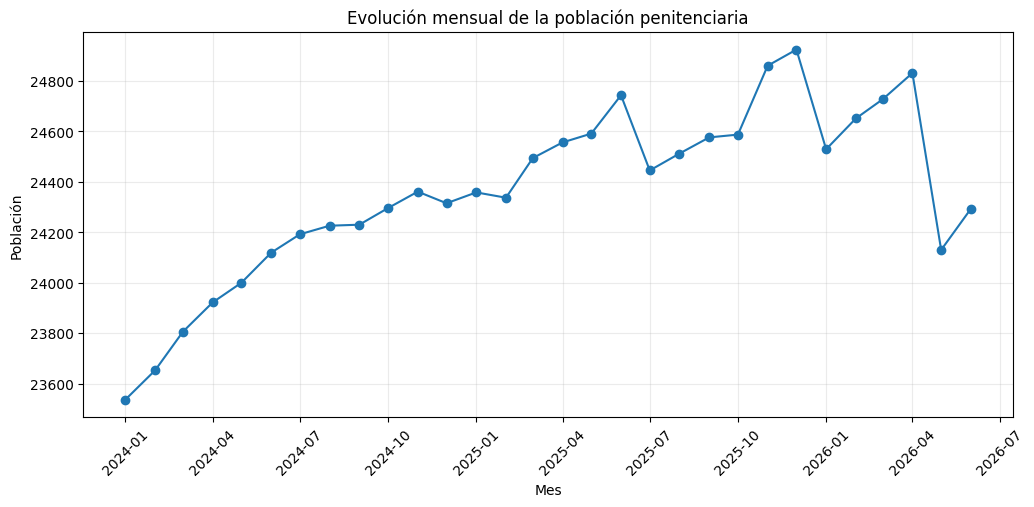

In [7]:

# Evolución mensual de la población
resumen_mensual["Periodo"] = pd.to_datetime(
    resumen_mensual["Año"].astype(str) + "-" +
    resumen_mensual["Mes"].astype(str).str.zfill(2) + "-01"
)

plt.figure(figsize=(12, 5))
plt.plot(resumen_mensual["Periodo"], resumen_mensual["Poblacion"], marker="o")
plt.title("Evolución mensual de la población penitenciaria")
plt.xlabel("Mes")
plt.ylabel("Población")
plt.grid(alpha=.25)
plt.xticks(rotation=45)
plt.show()


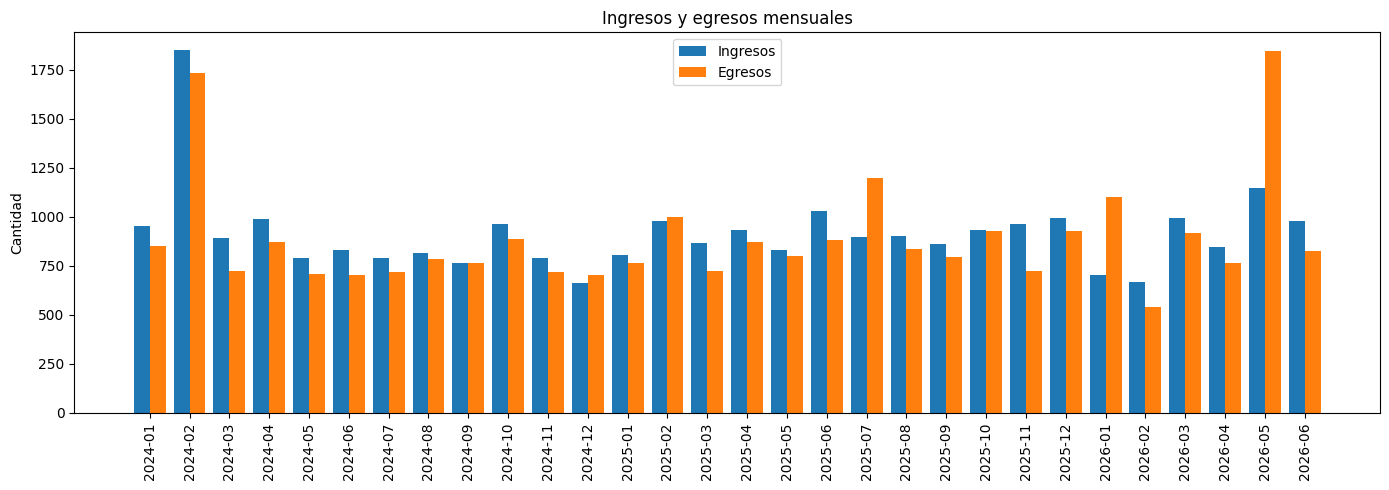

In [8]:

# Ingresos y egresos mensuales
x = np.arange(len(resumen_mensual))
w = 0.4

plt.figure(figsize=(14, 5))
plt.bar(x-w/2, resumen_mensual["Ingresos"], width=w, label="Ingresos")
plt.bar(x+w/2, resumen_mensual["Egresos"], width=w, label="Egresos")
plt.xticks(
    x,
    resumen_mensual["Periodo"].dt.strftime("%Y-%m"),
    rotation=90
)
plt.ylabel("Cantidad")
plt.title("Ingresos y egresos mensuales")
plt.legend()
plt.tight_layout()
plt.show()


In [9]:

# Cierre/último corte por año
cierre_anual = (
    df.sort_values("Fecha")
      .groupby(["Centro", "Año"], as_index=False)
      .tail(1)
      .groupby("Año", as_index=False)
      .agg(
          FechaCorte=("Fecha", "max"),
          Poblacion=("PoblacionPenal", "sum"),
          Capacidad=("Capacidad", "sum"),
          Camas=("Camas", "sum")
      )
)

cierre_anual["SobreCapacidad"] = cierre_anual["Poblacion"] - cierre_anual["Capacidad"]
cierre_anual["OcupacionCapacidad"] = cierre_anual["Poblacion"] / cierre_anual["Capacidad"] * 100
cierre_anual["OcupacionCamas"] = cierre_anual["Poblacion"] / cierre_anual["Camas"] * 100

display(cierre_anual)


,Año,FechaCorte,Poblacion,Capacidad,Camas,SobreCapacidad,OcupacionCapacidad,OcupacionCamas
0,2024,2024-12-31,24315,14496,14647,9819,167.735927,166.006691
1,2025,2025-12-30,24924,14700,14682,10224,169.551020,169.758888
2,2026,2026-06-30,24293,15145,15090,9148,160.402773,160.987409


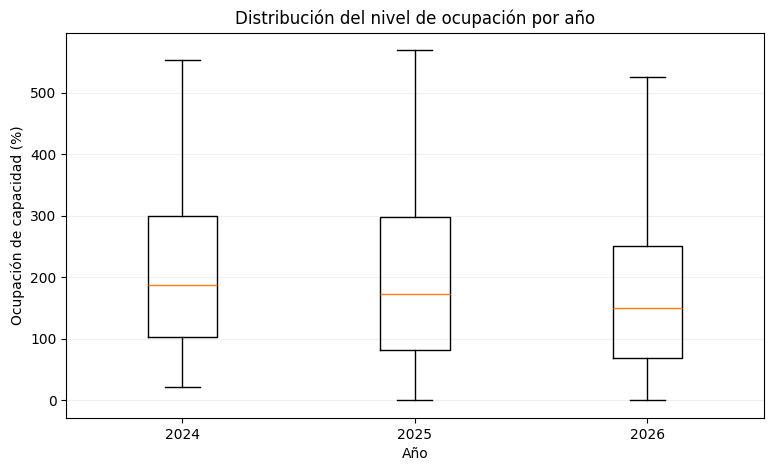

In [10]:

# Boxplot: ocupación de capacidad según año
años = sorted(df["Año"].dropna().unique())
datos = [df.loc[df["Año"] == a, "OcupacionCapacidad"].dropna() for a in años]

plt.figure(figsize=(9, 5))
plt.boxplot(datos, labels=años, showfliers=False)
plt.xlabel("Año")
plt.ylabel("Ocupación de capacidad (%)")
plt.title("Distribución del nivel de ocupación por año")
plt.grid(axis="y", alpha=.2)
plt.show()


In [11]:

# Centros con mayor sobrecapacidad en el último corte disponible
fecha_final = df["Fecha"].max()
ultimo = df[df["Fecha"] == fecha_final].copy()
ultimo = ultimo.sort_values("SobreCapacidadCalc", ascending=False)

display(
    ultimo[
        ["Provincia", "Centro", "PoblacionPenal", "Capacidad",
         "Camas", "SobreCapacidadCalc", "OcupacionCapacidad"]
    ].head(15)
)


,Provincia,Centro,PoblacionPenal,Capacidad,Camas,SobreCapacidadCalc,OcupacionCapacidad
9061,Panamá,Centro Penitenciario La Joya,4900,1568,1568,3332.0,312.500000
9966,Panamá,Centro Penitenciario La Joyita,4714,2837,2836,1877.0,166.161438
8156,Chiriquí,Centro Penitenciario De Chiriquí,2230,950,950,1280.0,234.736842
11776,Colón,Centro Penitenciario Nueva Esperanza,2520,1322,1322,1198.0,190.620272
14065,Bocas Del Toro,Cárcel Pública De Deborah,1020,292,292,728.0,349.315068
17662,Veraguas,Cárcel Púiblica De Santiago,629,150,29,479.0,419.333333
16757,Coclé,Cárcel Pública De Penonomé,673,200,198,473.0,336.500000
15852,Los Santos,Cárcel Pública De Las Tablas,374,80,133,294.0,467.500000
10871,Panamá,Centro Penitenciario La Nueva Joya,5641,5504,5504,137.0,102.489099
1792,Panamá,Centro De Detención De Tinajitas,393,280,396,113.0,140.357143


## A.1 Estadística descriptiva mensual por centro penitenciario

Para que las medidas de ingreso y egreso sean interpretables, primero se agregan los movimientos diarios a **totales mensuales por centro**. Luego se calculan, para cada centro, media, mediana, moda, desviación estándar y cuartiles 25 % y 75 % de esos totales mensuales.

Esto evita que la alta frecuencia de ceros diarios domine artificialmente la moda y la mediana.

In [12]:
# Totales mensuales de ingresos y egresos por centro
centro_mes_flujos = (
    df.groupby(["Centro", "Año", "Mes"], as_index=False)
      .agg(IngresoMensual=("Ingreso", "sum"),
           EgresoMensual=("Egreso", "sum"))
)

def moda_serie(s):
    m = s.mode(dropna=True)
    return m.iloc[0] if len(m) else np.nan

def resumen_estadistico_por_centro(data, variable, prefijo):
    return (
        data.groupby("Centro")[variable]
            .agg(
                **{
                    f"{prefijo}_Media": "mean",
                    f"{prefijo}_Mediana": "median",
                    f"{prefijo}_Moda": moda_serie,
                    f"{prefijo}_DesvEst": "std",
                    f"{prefijo}_Q1": lambda s: s.quantile(0.25),
                    f"{prefijo}_Q3": lambda s: s.quantile(0.75),
                    f"{prefijo}_Min": "min",
                    f"{prefijo}_Max": "max",
                }
            )
            .reset_index()
    )

res_ing = resumen_estadistico_por_centro(centro_mes_flujos, "IngresoMensual", "Ingreso")
res_egr = resumen_estadistico_por_centro(centro_mes_flujos, "EgresoMensual", "Egreso")

estadistica_centros = res_ing.merge(res_egr, on="Centro", how="outer")

columnas_num = estadistica_centros.select_dtypes(include=np.number).columns
estadistica_centros[columnas_num] = estadistica_centros[columnas_num].round(2)

display(estadistica_centros)

,Centro,Ingreso_Media,Ingreso_Mediana,Ingreso_Moda,Ingreso_DesvEst,Ingreso_Q1,Ingreso_Q3,Ingreso_Min,Ingreso_Max,Egreso_Media,Egreso_Mediana,Egreso_Moda,Egreso_DesvEst,Egreso_Q1,Egreso_Q3,Egreso_Min,Egreso_Max
0,C.D.P. De Punta Coco,0.30,0.0,0,1.15,0.00,0.00,0,5,0.67,0.0,0.0,2.04,0.00,0.00,0.0,9.0
1,Centro De Detención De Tinajitas,258.73,258.5,232,27.45,239.25,271.75,212,324,256.30,256.0,215.0,46.07,215.50,278.25,177.0,376.0
2,Centro De Rehabilitación El Renacer,17.83,3.0,2,37.91,2.00,26.00,0,202,19.40,14.0,14.0,14.62,8.25,29.50,1.0,57.0
3,Centro Femenino De Colón,2.73,3.0,3,1.76,1.00,4.00,0,7,3.53,3.0,1.0,3.66,1.25,4.00,0.0,19.0
4,Centro Femenino De Llano Marín,5.60,5.0,4,3.01,4.00,7.00,0,15,7.53,6.5,5.0,5.73,5.00,8.75,1.0,33.0
5,Centro Femenino De Panamá,17.97,18.0,18,6.87,15.00,23.00,0,30,29.10,18.0,15.0,35.95,15.00,25.75,0.0,181.0
6,Centro Femenino La Esmeralda,37.00,37.0,29,11.31,33.00,41.00,29,45,16.00,16.0,9.0,9.90,12.50,19.50,9.0,23.0
7,Centro Femenino Los Algarrobos,5.57,5.0,3,3.65,3.00,7.00,0,16,8.40,6.5,3.0,8.22,3.25,9.00,1.0,41.0
8,Centro Masculino De Llano Marín,0.63,0.0,0,1.30,0.00,0.75,0,5,0.90,1.0,0.0,1.21,0.00,1.00,0.0,6.0
9,Centro Penitenciario De Chiriquí,64.17,57.5,54,36.80,51.00,62.50,27,206,63.37,46.5,46.0,61.60,41.50,52.75,33.0,362.0


## A.2 Boxplots mensuales de ingresos y egresos: comparación simultánea 2024–2026

Cada mes se presenta una sola vez en el eje X. Dentro de cada mes, las cajas se agrupan horizontalmente en el orden **2024 – 2025 – 2026**, de modo que la comparación entre años se realiza en una misma figura. Además, **cada año tiene un color fijo** para facilitar la identificación visual en todos los meses.

- **2024**: azul
- **2025**: naranja
- **2026**: verde

Cada caja representa la distribución de los **totales mensuales por centro penitenciario**.

Para **enero–junio** se observan tres cajas por mes. Para **julio–diciembre** solo se muestran 2024 y 2025, porque la base observada termina el 30 de junio de 2026; no se generan datos ficticios para completar el año.

> Los registros del **28, 29 y 30 de enero de 2026** ya fueron excluidos antes de construir estos agregados mensuales.

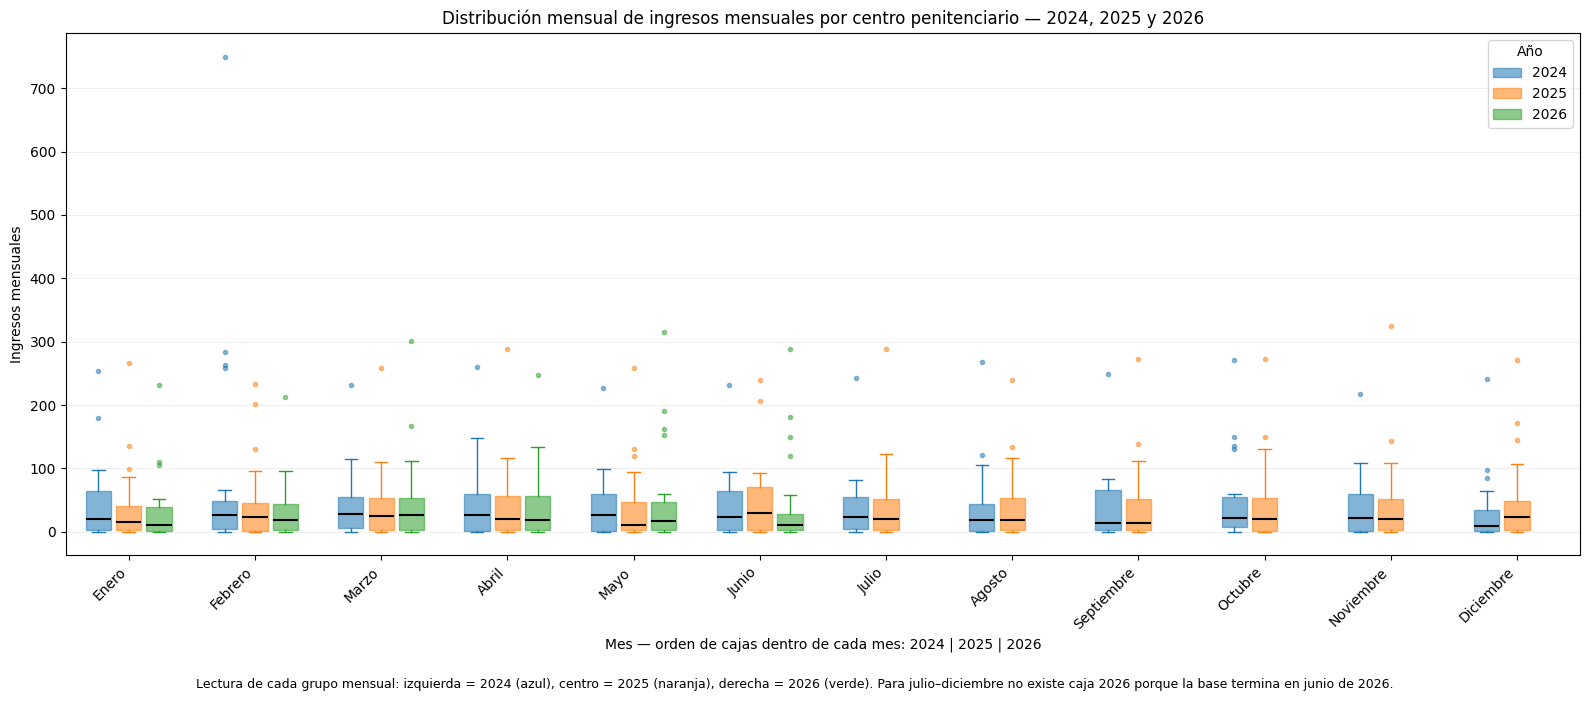

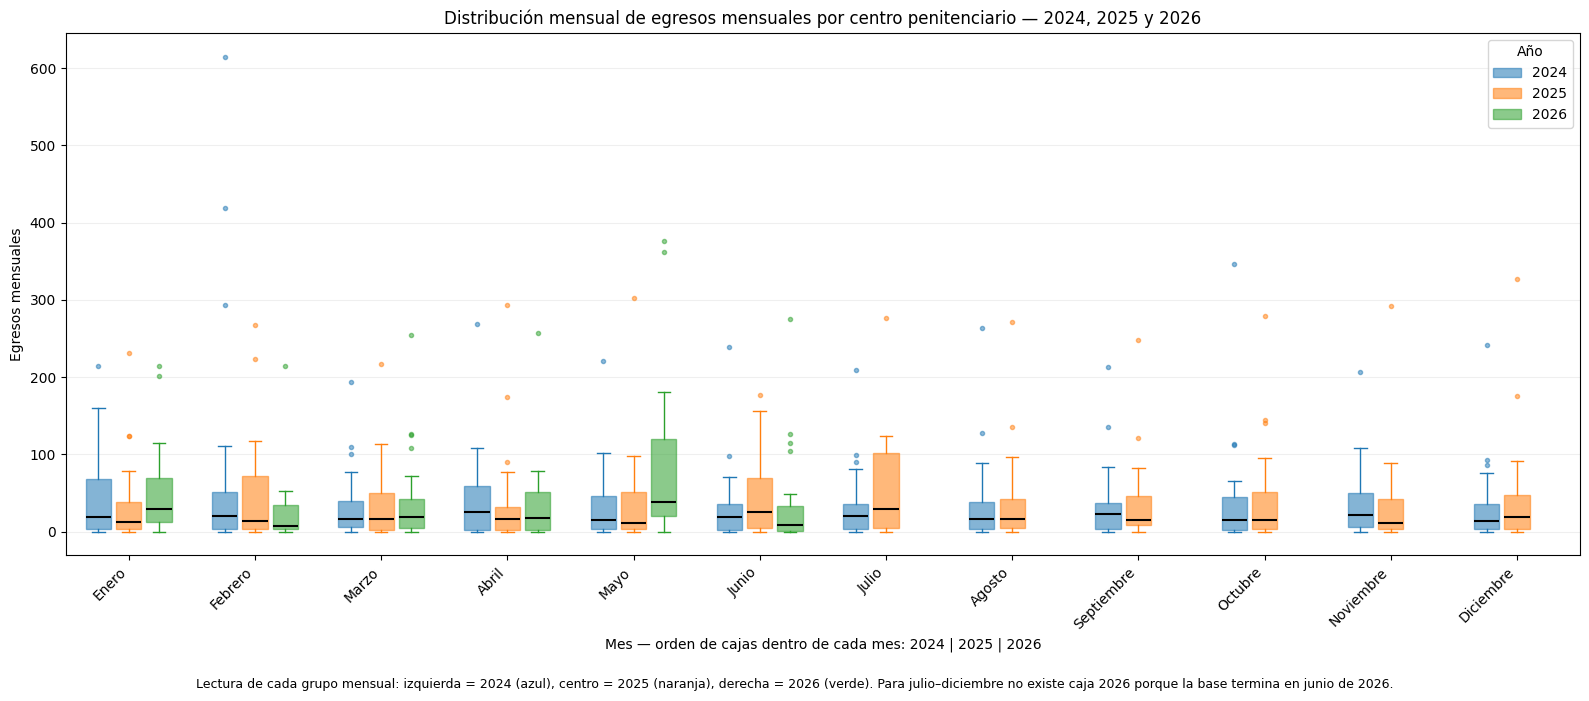

In [13]:

meses_es = ["Enero","Febrero","Marzo","Abril","Mayo","Junio",
            "Julio","Agosto","Septiembre","Octubre","Noviembre","Diciembre"]

from matplotlib.patches import Patch

def boxplot_mensual_tres_anios(data, variable, etiqueta):
    """
    Un único gráfico por variable.
    Cada mes ocupa una posición central y, dentro del mes, las cajas aparecen:
    izquierda = 2024, centro = 2025, derecha = 2026.
    Cada año mantiene un color fijo para facilitar la lectura.
    """
    anios = [2024, 2025, 2026]
    desplazamientos = {2024: -0.24, 2025: 0.00, 2026: 0.24}
    colores = {2024: "tab:blue", 2025: "tab:orange", 2026: "tab:green"}

    fig, ax = plt.subplots(figsize=(16, 7))

    for anio in anios:
        for mes in range(1, 13):
            valores = data.loc[
                (data["Año"] == anio) & (data["Mes"] == mes),
                variable
            ].dropna().values

            if len(valores) == 0:
                continue

            posicion = mes + desplazamientos[anio]
            bp = ax.boxplot(
                [valores],
                positions=[posicion],
                widths=0.20,
                showfliers=True,
                manage_ticks=False,
                patch_artist=True,
                boxprops=dict(facecolor=colores[anio], alpha=0.55, color=colores[anio]),
                medianprops=dict(color="black", linewidth=1.5),
                whiskerprops=dict(color=colores[anio]),
                capprops=dict(color=colores[anio]),
                flierprops=dict(marker='o', markerfacecolor=colores[anio], markeredgecolor=colores[anio], markersize=3, alpha=0.5)
            )

    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(meses_es, rotation=45, ha="right")
    ax.set_xlim(0.5, 12.5)
    ax.set_xlabel("Mes — orden de cajas dentro de cada mes: 2024 | 2025 | 2026")
    ax.set_ylabel(etiqueta)
    ax.set_title(f"Distribución mensual de {etiqueta.lower()} por centro penitenciario — 2024, 2025 y 2026")
    ax.grid(axis="y", alpha=.2)

    leyenda = [
        Patch(facecolor=colores[2024], edgecolor=colores[2024], alpha=0.55, label="2024"),
        Patch(facecolor=colores[2025], edgecolor=colores[2025], alpha=0.55, label="2025"),
        Patch(facecolor=colores[2026], edgecolor=colores[2026], alpha=0.55, label="2026"),
    ]
    ax.legend(handles=leyenda, title="Año", loc="upper right")

    fig.text(
        0.5, 0.01,
        "Lectura de cada grupo mensual: izquierda = 2024 (azul), centro = 2025 (naranja), derecha = 2026 (verde). "
        "Para julio–diciembre no existe caja 2026 porque la base termina en junio de 2026.",
        ha="center", fontsize=9
    )
    plt.tight_layout(rect=[0, 0.04, 1, 1])
    plt.show()

boxplot_mensual_tres_anios(
    centro_mes_flujos,
    "IngresoMensual",
    "Ingresos mensuales"
)

boxplot_mensual_tres_anios(
    centro_mes_flujos,
    "EgresoMensual",
    "Egresos mensuales"
)


## A.3 Temporalidad mensual de población, ingresos y egresos

La población se representa como **stock al último corte de cada mes**. Los ingresos y egresos se representan como **flujos acumulados mensuales**.

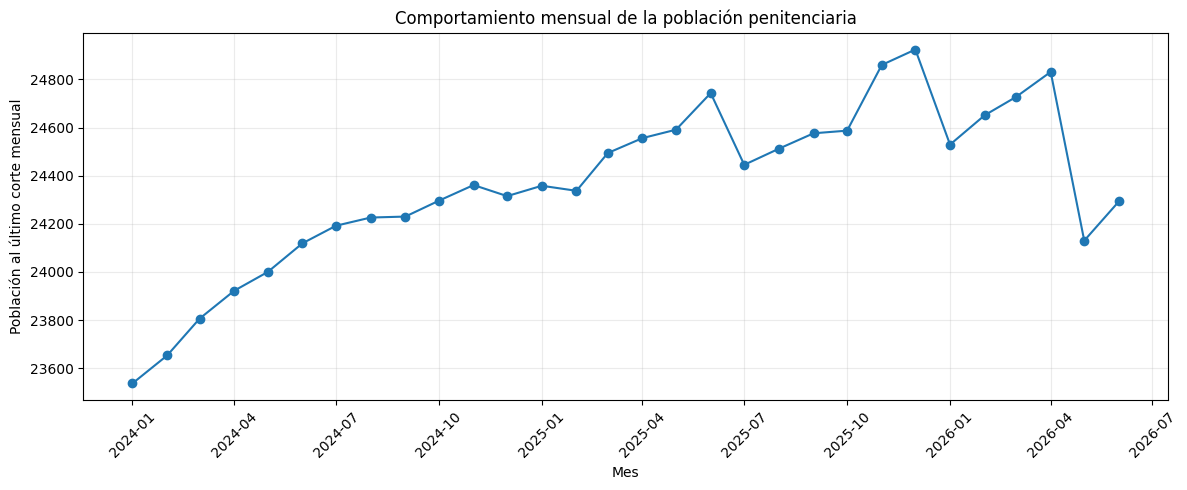

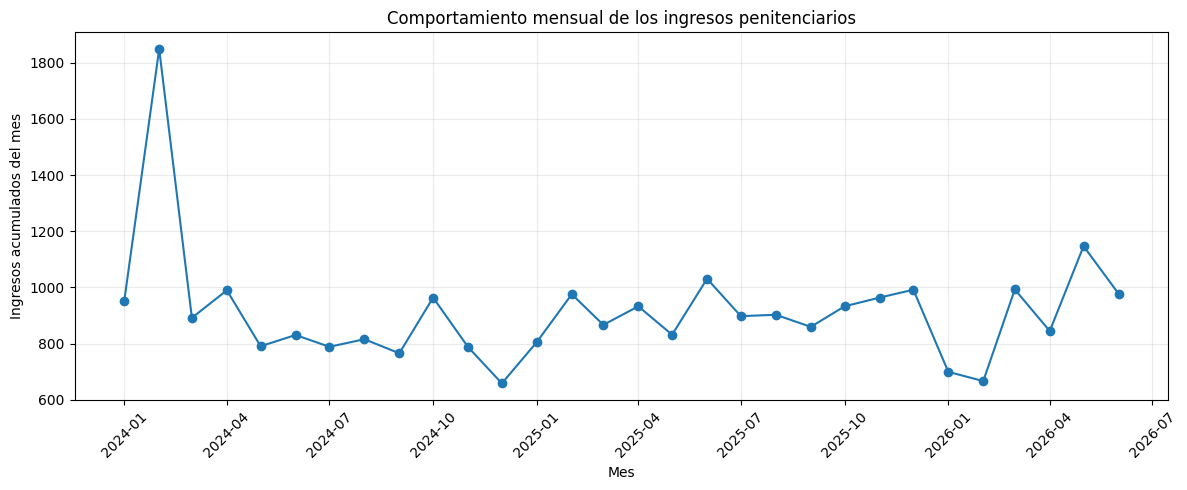

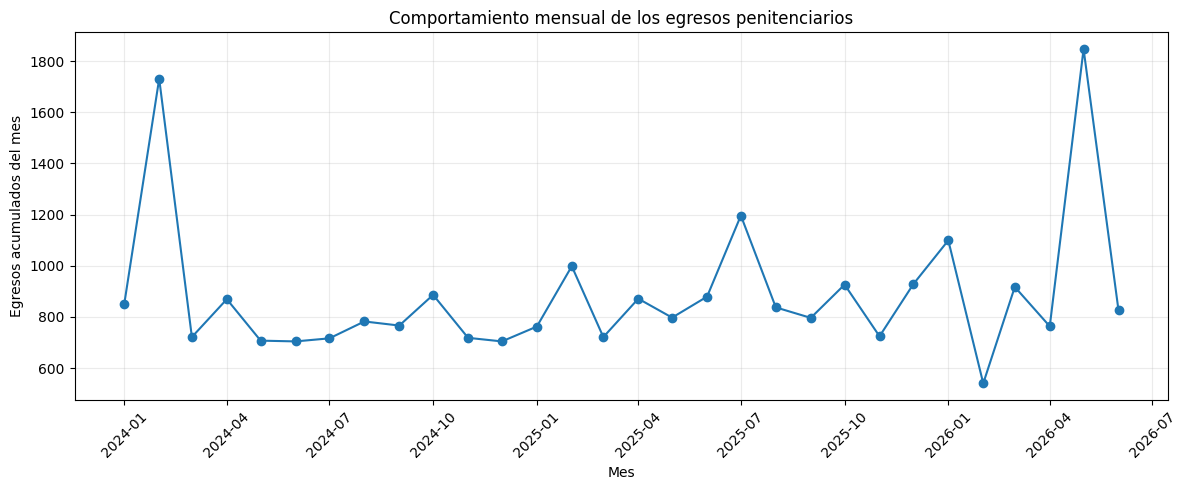

In [14]:
# Una figura independiente para cada serie temporal
plt.figure(figsize=(12,5))
plt.plot(resumen_mensual["Periodo"], resumen_mensual["Poblacion"], marker="o")
plt.title("Comportamiento mensual de la población penitenciaria")
plt.xlabel("Mes")
plt.ylabel("Población al último corte mensual")
plt.grid(alpha=.25)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,5))
plt.plot(resumen_mensual["Periodo"], resumen_mensual["Ingresos"], marker="o")
plt.title("Comportamiento mensual de los ingresos penitenciarios")
plt.xlabel("Mes")
plt.ylabel("Ingresos acumulados del mes")
plt.grid(alpha=.25)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,5))
plt.plot(resumen_mensual["Periodo"], resumen_mensual["Egresos"], marker="o")
plt.title("Comportamiento mensual de los egresos penitenciarios")
plt.xlabel("Mes")
plt.ylabel("Egresos acumulados del mes")
plt.grid(alpha=.25)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## A.4 Comparación mensual 2024, 2025 y 2026

Para evitar gráficos diarios difíciles de leer, se comparan los mismos meses entre **2024, 2025 y 2026**. Esta sección permite observar si los movimientos de ingresos y egresos, así como la población al cierre mensual, aumentaron, disminuyeron o mantuvieron patrones semejantes entre los tres años.

Dado que la base observada termina en junio de 2026, para **julio–diciembre** solamente aparecen 2024 y 2025.

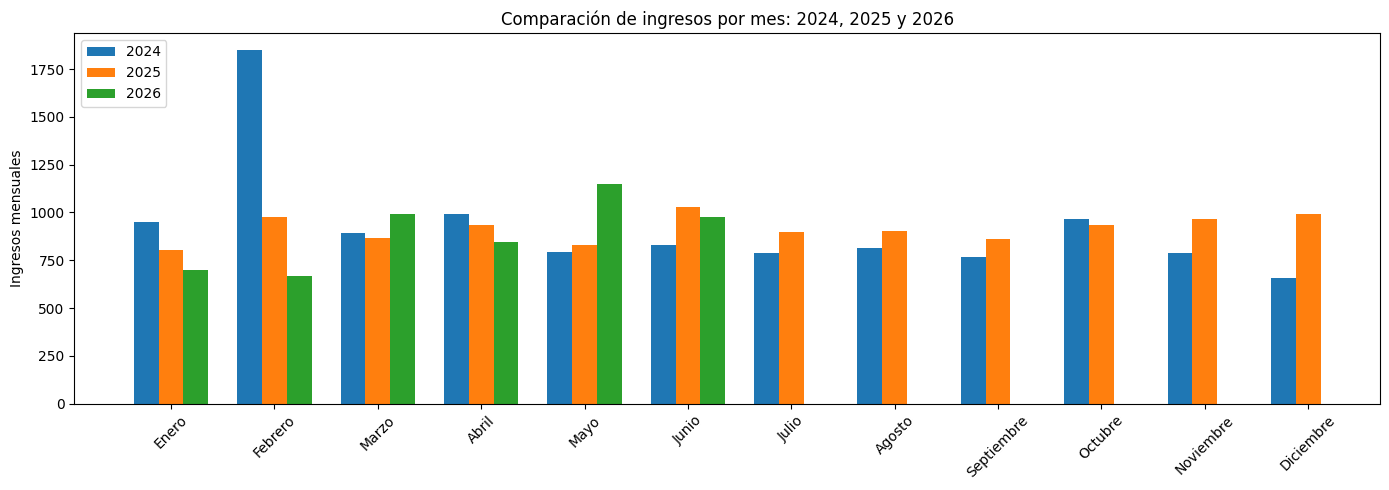

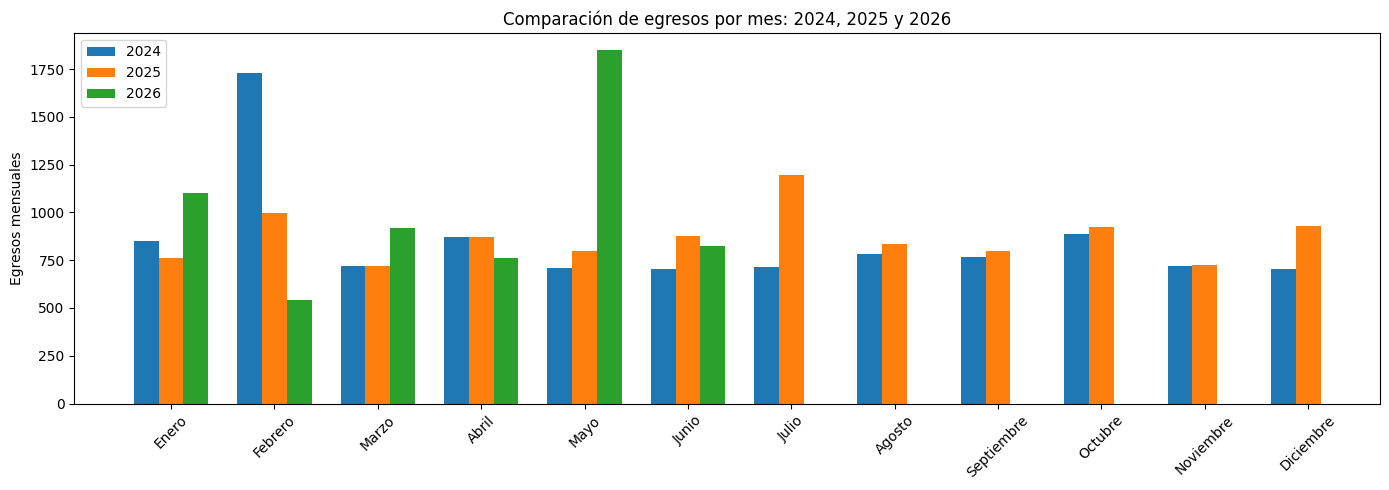

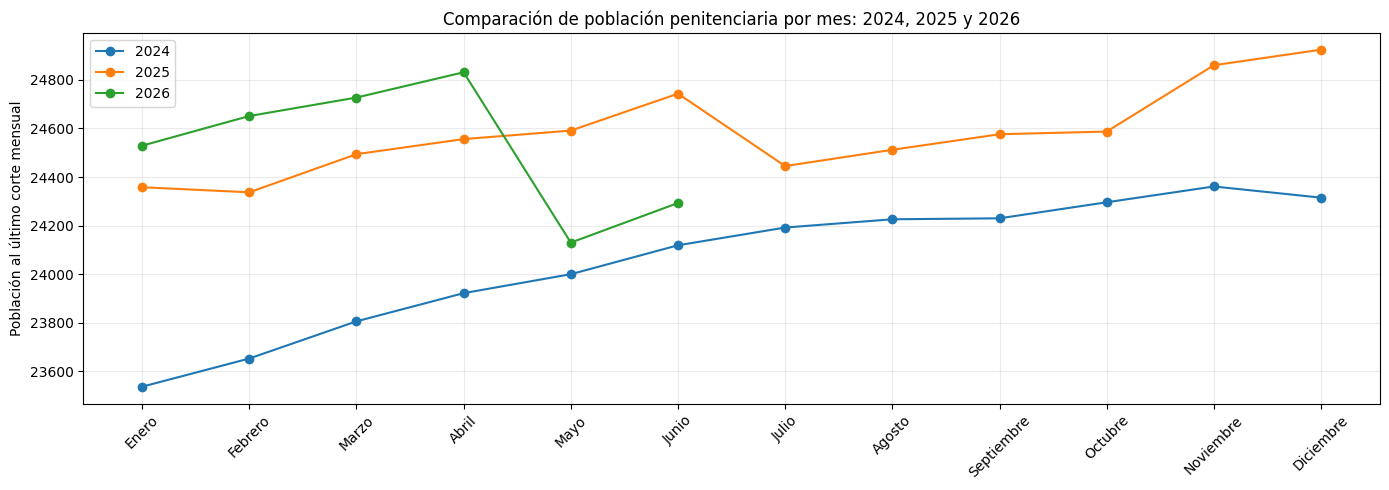

,Mes,Poblacion_2024,Poblacion_2025,Poblacion_2026,VarPoblacion_25_vs_24_%,VarPoblacion_26_vs_25_%,Ingresos_2024,Ingresos_2025,Ingresos_2026,VarIngresos_25_vs_24_%,VarIngresos_26_vs_25_%,Egresos_2024,Egresos_2025,Egresos_2026,VarEgresos_25_vs_24_%,VarEgresos_26_vs_25_%
Mes,,,,,,,,,,,,,,,,
1,Enero,23537.0,24358.0,24529.0,3.49,0.70,952.0,806.0,700.0,-15.34,-13.15,850.0,762.0,1099.0,-10.35,44.23
2,Febrero,23653.0,24337.0,24651.0,2.89,1.29,1848.0,976.0,667.0,-47.19,-31.66,1731.0,998.0,540.0,-42.35,-45.89
3,Marzo,23806.0,24494.0,24727.0,2.89,0.95,892.0,867.0,993.0,-2.80,14.53,721.0,721.0,917.0,0.00,27.18
4,Abril,23922.0,24556.0,24831.0,2.65,1.12,990.0,933.0,845.0,-5.76,-9.43,869.0,871.0,763.0,0.23,-12.40
5,Mayo,24000.0,24591.0,24130.0,2.46,-1.87,791.0,832.0,1147.0,5.18,37.86,707.0,797.0,1847.0,12.73,131.74
6,Junio,24119.0,24743.0,24293.0,2.59,-1.82,831.0,1031.0,978.0,24.07,-5.14,704.0,879.0,825.0,24.86,-6.14
7,Julio,24192.0,24445.0,NaN,1.05,NaN,789.0,898.0,NaN,13.81,NaN,716.0,1196.0,NaN,67.04,NaN
8,Agosto,24226.0,24512.0,NaN,1.18,NaN,816.0,903.0,NaN,10.66,NaN,782.0,837.0,NaN,7.03,NaN
9,Septiembre,24230.0,24576.0,NaN,1.43,NaN,766.0,860.0,NaN,12.27,NaN,766.0,796.0,NaN,3.92,NaN


In [15]:

comp_2426 = resumen_mensual[resumen_mensual["Año"].isin([2024, 2025, 2026])].copy()

pivot_ing = comp_2426.pivot(index="Mes", columns="Año", values="Ingresos").reindex(range(1,13))
pivot_egr = comp_2426.pivot(index="Mes", columns="Año", values="Egresos").reindex(range(1,13))
pivot_pob = comp_2426.pivot(index="Mes", columns="Año", values="Poblacion").reindex(range(1,13))

# asegurar columnas en orden
for pivot in [pivot_ing, pivot_egr, pivot_pob]:
    for anio in [2024, 2025, 2026]:
        if anio not in pivot.columns:
            pivot[anio] = np.nan
    pivot.sort_index(axis=1, inplace=True)

x = np.arange(12)
w = 0.24

# Ingresos: barras agrupadas por mes
plt.figure(figsize=(14,5))
plt.bar(x-w, pivot_ing[2024], width=w, label="2024")
plt.bar(x,   pivot_ing[2025], width=w, label="2025")
plt.bar(x+w, pivot_ing[2026], width=w, label="2026")
plt.xticks(x, meses_es, rotation=45)
plt.ylabel("Ingresos mensuales")
plt.title("Comparación de ingresos por mes: 2024, 2025 y 2026")
plt.legend()
plt.tight_layout()
plt.show()

# Egresos: barras agrupadas por mes
plt.figure(figsize=(14,5))
plt.bar(x-w, pivot_egr[2024], width=w, label="2024")
plt.bar(x,   pivot_egr[2025], width=w, label="2025")
plt.bar(x+w, pivot_egr[2026], width=w, label="2026")
plt.xticks(x, meses_es, rotation=45)
plt.ylabel("Egresos mensuales")
plt.title("Comparación de egresos por mes: 2024, 2025 y 2026")
plt.legend()
plt.tight_layout()
plt.show()

# Población de cierre mensual
plt.figure(figsize=(14,5))
plt.plot(x, pivot_pob[2024], marker="o", label="2024")
plt.plot(x, pivot_pob[2025], marker="o", label="2025")
plt.plot(x, pivot_pob[2026], marker="o", label="2026")
plt.xticks(x, meses_es, rotation=45)
plt.ylabel("Población al último corte mensual")
plt.title("Comparación de población penitenciaria por mes: 2024, 2025 y 2026")
plt.legend()
plt.grid(alpha=.25)
plt.tight_layout()
plt.show()

comparacion_2426 = pd.DataFrame({
    "Mes": meses_es,
    "Poblacion_2024": pivot_pob[2024].values,
    "Poblacion_2025": pivot_pob[2025].values,
    "Poblacion_2026": pivot_pob[2026].values,
    "VarPoblacion_25_vs_24_%": ((pivot_pob[2025] / pivot_pob[2024]) - 1) * 100,
    "VarPoblacion_26_vs_25_%": ((pivot_pob[2026] / pivot_pob[2025]) - 1) * 100,
    "Ingresos_2024": pivot_ing[2024].values,
    "Ingresos_2025": pivot_ing[2025].values,
    "Ingresos_2026": pivot_ing[2026].values,
    "VarIngresos_25_vs_24_%": ((pivot_ing[2025] / pivot_ing[2024]) - 1) * 100,
    "VarIngresos_26_vs_25_%": ((pivot_ing[2026] / pivot_ing[2025]) - 1) * 100,
    "Egresos_2024": pivot_egr[2024].values,
    "Egresos_2025": pivot_egr[2025].values,
    "Egresos_2026": pivot_egr[2026].values,
    "VarEgresos_25_vs_24_%": ((pivot_egr[2025] / pivot_egr[2024]) - 1) * 100,
    "VarEgresos_26_vs_25_%": ((pivot_egr[2026] / pivot_egr[2025]) - 1) * 100,
}).round(2)

display(comparacion_2426)



# BLOQUE B — CONTRASTE DE HIPÓTESIS

Se utiliza una regresión explicativa con efectos fijos de centro y mes.  
Para reducir el problema de dependencia entre observaciones del mismo centro, se calculan **errores estándar agrupados por centro**.

Modelo conceptual:

\[
Poblacion_{t+30} =
eta_0 +
eta_1 Poblacion_t +
eta_2 Ingresos_{30d} +
eta_3 Egresos_{30d} +
eta_4 Capacidad +
eta_5 Camas +
eta_6 Tendencia +
EfectoCentro +
EfectoMes +
\epsilon
\]

Los valores p de `Ingreso_30d`, `Egreso_30d` y `Tendencia` permiten contrastar las hipótesis específicas.


In [16]:

vars_h = [
    "Poblacion_30d", "PoblacionPenal", "Ingreso_30d", "Egreso_30d",
    "Capacidad", "Camas", "Tendencia", "Mes", "Centro"
]

datos_h = df_modelo[vars_h].dropna().copy()

formula = (
    "Poblacion_30d ~ PoblacionPenal + Ingreso_30d + Egreso_30d + "
    "Capacidad + Camas + Tendencia + C(Mes) + C(Centro)"
)

modelo_hipotesis = smf.ols(formula, data=datos_h).fit(
    cov_type="cluster",
    cov_kwds={"groups": datos_h["Centro"]}
)

print(modelo_hipotesis.summary())


                            OLS Regression Results                            
Dep. Variable:          Poblacion_30d   R-squared:                       0.998
Model:                            OLS   Adj. R-squared:                  0.998
Method:                 Least Squares   F-statistic:                 2.927e+04
Date:                Mon, 21 Sep 2026   Prob (F-statistic):           4.46e-42
Time:                        22:28:04   Log-Likelihood:            -1.0313e+05
No. Observations:               17680   AIC:                         2.063e+05
Df Residuals:                   17641   BIC:                         2.067e+05
Df Model:                          38                                         
Covariance Type:              cluster                                         
                                                        coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------

/usr/local/lib/python3.13/dist-packages/statsmodels/base/model.py:1988: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 38, but rank is 17
  res = self.wald_test(



### Interpretación de las hipótesis

- **Hipótesis general:** revisar el valor p de la prueba F global.
- **Tendencia:** revisar `Tendencia`.
- **Ingresos:** revisar `Ingreso_30d`.
- **Egresos:** revisar `Egreso_30d`.

Si \(p<0.05\), se rechaza \(H_0\) para el efecto evaluado.

> La significancia estadística no implica por sí sola una magnitud importante. Siempre deben revisarse el signo y tamaño del coeficiente y los intervalos de confianza.



# BLOQUE C — DIAGNÓSTICO DE RESIDUALES DE LA REGRESIÓN


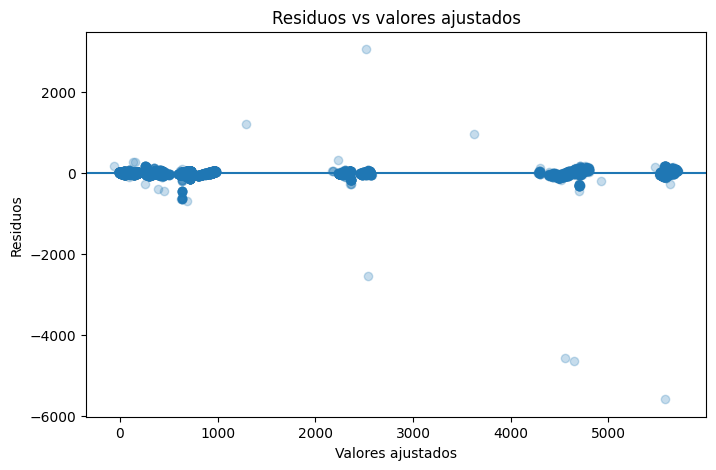

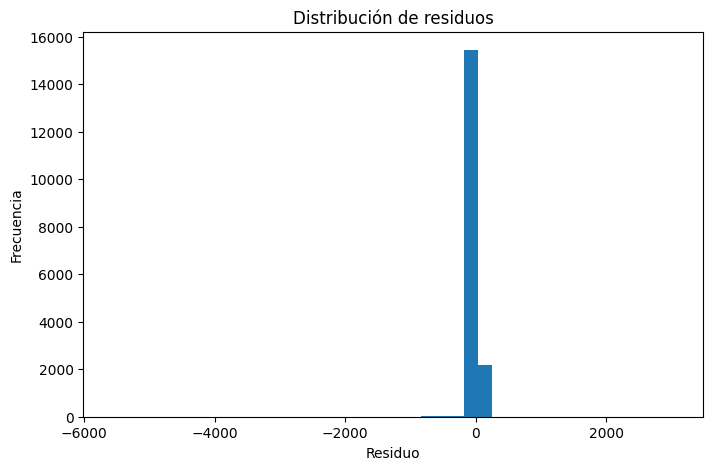

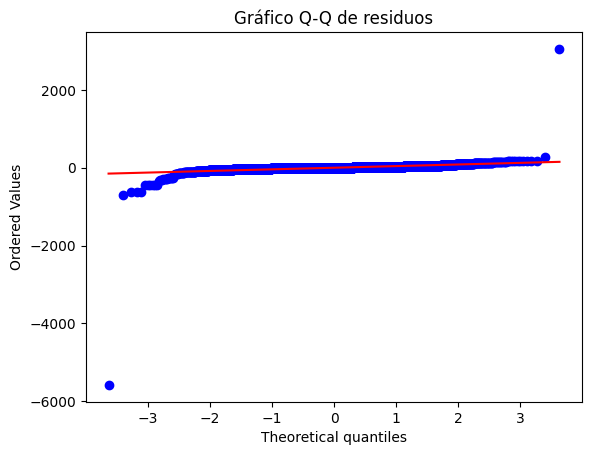

Durbin-Watson: 1.5608339530924191
Breusch-Pagan:
{'LM': np.float64(313.71486764307866), 'p_LM': np.float64(4.395113338144956e-45), 'F': np.float64(8.386249469366389), 'p_F': np.float64(1.4901900656519174e-45)}


In [17]:

residuos = modelo_hipotesis.resid
ajustados = modelo_hipotesis.fittedvalues

plt.figure(figsize=(8, 5))
plt.scatter(ajustados, residuos, alpha=.25)
plt.axhline(0)
plt.xlabel("Valores ajustados")
plt.ylabel("Residuos")
plt.title("Residuos vs valores ajustados")
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(residuos, bins=40)
plt.title("Distribución de residuos")
plt.xlabel("Residuo")
plt.ylabel("Frecuencia")
plt.show()

stats.probplot(residuos.sample(min(5000, len(residuos)), random_state=123), dist="norm", plot=plt)
plt.title("Gráfico Q-Q de residuos")
plt.show()

print("Durbin-Watson:", durbin_watson(residuos))

bp = het_breuschpagan(residuos, modelo_hipotesis.model.exog)
print("Breusch-Pagan:")
print({
    "LM": bp[0],
    "p_LM": bp[1],
    "F": bp[2],
    "p_F": bp[3]
})



# BLOQUE D — PREPARACIÓN PARA PRONÓSTICO

Se utiliza una separación estrictamente temporal.

- **Entrenamiento:** objetivos conocidos hasta el 31 de diciembre de 2025.
- **Prueba:** orígenes de pronóstico desde el 1 de enero de 2026.
- No se usa división aleatoria (`train_test_split`), porque produciría fuga temporal.


In [18]:

features_num = [
    "PoblacionPenal",
    "PoblacionLag1",
    "PoblacionLag7",
    "PoblacionLag30",
    "MediaMovil7",
    "MediaMovil30",
    "Ingreso_7d",
    "Egreso_7d",
    "Ingreso_30d",
    "Egreso_30d",
    "Capacidad",
    "Camas",
    "Tendencia",
    "Mes",
    "Trimestre",
    "DiaSemana"
]

features_cat = ["Centro", "Provincia"]

columnas = (
    features_num + features_cat +
    ["Fecha", "FechaObjetivo", "Poblacion_30d"]
)

model_data = df_modelo[columnas].dropna().copy()

train = model_data[model_data["FechaObjetivo"] <= "2025-12-31"].copy()
test = model_data[
    (model_data["Fecha"] >= "2026-01-01") &
    (model_data["FechaObjetivo"] <= df["Fecha"].max())
].copy()

X_train = train[features_num + features_cat]
y_train = train["Poblacion_30d"]

X_test = test[features_num + features_cat]
y_test = test["Poblacion_30d"]

print("Entrenamiento:", len(train))
print("Prueba:", len(test))
print("Centros en prueba:", test["Centro"].nunique())


Entrenamiento: 13557
Prueba: 2971
Centros en prueba: 21


In [19]:

def metricas(nombre, y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    err = y_true - y_pred

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    mask = y_true != 0
    mape = np.mean(np.abs(err[mask] / y_true[mask])) * 100 if mask.any() else np.nan
    wape = np.sum(np.abs(err)) / np.sum(np.abs(y_true)) * 100 if np.sum(np.abs(y_true)) else np.nan

    return {
        "Modelo": nombre,
        "MAE": mae,
        "RMSE": rmse,
        "MAPE_%": mape,
        "WAPE_%": wape,
        "R2": r2
    }

resultados = []



## Modelo 1 — Media móvil de 30 días

Se utiliza como modelo de referencia. Un modelo más complejo debería superar razonablemente esta línea base.


In [20]:

pred_ma = test["MediaMovil30"].values
resultados.append(metricas("Media móvil 30d", y_test, pred_ma))



## Modelo 2 — Regresión lineal predictiva


In [21]:

preprocesamiento = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), features_num),
        ("cat", OneHotEncoder(handle_unknown="ignore"), features_cat)
    ]
)

modelo_reg = Pipeline([
    ("prep", preprocesamiento),
    ("modelo", LinearRegression())
])

modelo_reg.fit(X_train, y_train)
pred_reg = modelo_reg.predict(X_test)

resultados.append(metricas("Regresión", y_test, pred_reg))



## Modelo 3 — XGBoost


In [22]:

prep_xgb = ColumnTransformer(
    transformers=[
        ("num", "passthrough", features_num),
        ("cat", OneHotEncoder(handle_unknown="ignore"), features_cat)
    ]
)

modelo_xgb = Pipeline([
    ("prep", prep_xgb),
    ("modelo", XGBRegressor(
        n_estimators=500,
        max_depth=5,
        learning_rate=0.04,
        subsample=0.85,
        colsample_bytree=0.85,
        objective="reg:squarederror",
        random_state=123,
        n_jobs=-1
    ))
])

modelo_xgb.fit(X_train, y_train)
pred_xgb = modelo_xgb.predict(X_test)

resultados.append(metricas("XGBoost", y_test, pred_xgb))



## Modelo opcional — Random Forest

Puede incluirse como quinto modelo o utilizarse en lugar de XGBoost si el profesor solicita específicamente un ensamble de árboles.


In [23]:

prep_rf = ColumnTransformer(
    transformers=[
        ("num", "passthrough", features_num),
        ("cat", OneHotEncoder(handle_unknown="ignore"), features_cat)
    ]
)

modelo_rf = Pipeline([
    ("prep", prep_rf),
    ("modelo", RandomForestRegressor(
        n_estimators=350,
        max_depth=18,
        min_samples_leaf=2,
        random_state=123,
        n_jobs=-1
    ))
])

modelo_rf.fit(X_train, y_train)
pred_rf = modelo_rf.predict(X_test)

resultados.append(metricas("Random Forest", y_test, pred_rf))



# BLOQUE E — SARIMA/SARIMAX

La base diaria permite trabajar con una estacionalidad semanal \(s=7\), lo que es mucho más defendible que aplicar un SARIMA mensual con únicamente 30 meses.

Modelo inicial:

\[
SARIMA(1,1,1)(1,0,0)_7
\]

Para comparar AIC se prueban varias especificaciones **dentro de la familia SARIMA**.  
AIC **no debe utilizarse para decidir entre SARIMA, XGBoost, Random Forest y media móvil**.


In [24]:

# Ejemplo de selección por AIC para un centro
CENTRO_EJEMPLO = "Centro Penitenciario La Joya"

serie = (
    df[df["Centro"] == CENTRO_EJEMPLO]
    .set_index("Fecha")["PoblacionPenal"]
    .asfreq("D")
    .interpolate(limit_direction="both")
)

serie_train = serie.loc[:"2025-12-31"]

candidatos = [
    ((1,1,0), (0,0,0,0)),
    ((1,1,1), (0,0,0,0)),
    ((2,1,1), (0,0,0,0)),
    ((1,1,1), (1,0,0,7)),
    ((2,1,1), (1,0,0,7)),
]

tabla_aic = []

for order, seasonal in candidatos:
    try:
        fit = SARIMAX(
            serie_train,
            order=order,
            seasonal_order=seasonal,
            enforce_stationarity=False,
            enforce_invertibility=False
        ).fit(disp=False)

        tabla_aic.append({
            "order": str(order),
            "seasonal_order": str(seasonal),
            "AIC": fit.aic,
            "BIC": fit.bic
        })
    except Exception as e:
        print("No convergió:", order, seasonal, e)

tabla_aic = pd.DataFrame(tabla_aic).sort_values("AIC")
display(tabla_aic)


,order,seasonal_order,AIC,BIC
4,"(2, 1, 1)","(1, 0, 0, 7)",9556.257429,9579.160625
3,"(1, 1, 1)","(1, 0, 0, 7)",9566.511656,9584.839757
1,"(1, 1, 1)","(0, 0, 0, 0)",9638.016038,9651.786941
2,"(2, 1, 1)","(0, 0, 0, 0)",9640.009615,9658.370819
0,"(1, 1, 0)","(0, 0, 0, 0)",9890.659505,9899.842853



## Evaluación SARIMA a 30 días con orígenes mensuales

Para evitar cientos de reajustes diarios, se utilizan cinco orígenes de pronóstico en 2026.  
Cada pronóstico se realiza utilizando solamente información conocida hasta el origen.


In [25]:

origenes = pd.to_datetime([
    "2026-01-31",
    "2026-02-28",
    "2026-03-31",
    "2026-04-30",
    "2026-05-31"
])

centros_sarima = [
    c for c, n in df.groupby("Centro").size().items()
    if n >= 700
]

pred_sarima = []

for centro in centros_sarima:
    serie_full = (
        df[df["Centro"] == centro]
        .set_index("Fecha")["PoblacionPenal"]
        .sort_index()
        .asfreq("D")
        .interpolate(limit_direction="both")
    )

    for origen in origenes:
        fecha_obj = origen + pd.Timedelta(days=30)

        if origen not in serie_full.index or fecha_obj not in serie_full.index:
            continue

        y_hist = serie_full.loc[:origen]

        if len(y_hist) < 200:
            continue

        try:
            fit = SARIMAX(
                y_hist,
                order=(1,1,1),
                seasonal_order=(1,0,0,7),
                enforce_stationarity=False,
                enforce_invertibility=False
            ).fit(disp=False)

            forecast = fit.forecast(30)

            pred_sarima.append({
                "Centro": centro,
                "Fecha": origen,
                "FechaObjetivo": fecha_obj,
                "Real": float(serie_full.loc[fecha_obj]),
                "Pred_SARIMA": float(forecast.iloc[-1]),
                "AIC": fit.aic
            })

        except Exception as e:
            print("Error SARIMA:", centro, origen.date(), e)

sarima_eval = pd.DataFrame(pred_sarima)
display(sarima_eval.head())

if len(sarima_eval):
    resultados.append(
        metricas(
            "SARIMA",
            sarima_eval["Real"],
            sarima_eval["Pred_SARIMA"]
        )
    )


,Centro,Fecha,FechaObjetivo,Real,Pred_SARIMA,AIC
0,C.D.P. De Punta Coco,2026-01-31,2026-03-02,6.0,6.000005,331.599044
1,C.D.P. De Punta Coco,2026-02-28,2026-03-30,6.0,6.000000,315.106771
2,C.D.P. De Punta Coco,2026-03-31,2026-04-30,6.0,6.000000,295.677731
3,C.D.P. De Punta Coco,2026-04-30,2026-05-30,10.0,6.000000,275.747836
4,Centro De Detención De Tinajitas,2026-01-31,2026-03-02,402.0,403.211527,6827.850582



# BLOQUE F — COMPARACIÓN DE MODELOS

Para la selección general use **MAE, RMSE, MAPE/WAPE y \(R^2\)**.

- Menor MAE: menor error absoluto promedio.
- Menor RMSE: castiga más los errores grandes.
- Menor MAPE/WAPE: menor error relativo.
- Mayor \(R^2\): mayor proporción de variabilidad explicada.

**AIC/BIC:** exclusivamente para comparar modelos probabilísticos comparables, por ejemplo distintas especificaciones ARIMA/SARIMA.


In [26]:

tabla_modelos = pd.DataFrame(resultados).sort_values("RMSE")
display(tabla_modelos)

if len(tabla_modelos):
    mejor = tabla_modelos.iloc[0]
    print(
        f"Según RMSE, el mejor modelo en esta evaluación es "
        f"{mejor['Modelo']} con RMSE={mejor['RMSE']:.2f}."
    )


,Modelo,MAE,RMSE,MAPE_%,WAPE_%,R2
0,Media móvil 30d,22.148996,58.366177,14.202169,1.871355,0.998886
1,Regresión,23.086166,59.581847,25.507948,1.950535,0.998839
3,Random Forest,27.631595,63.561387,21.398501,2.334576,0.998679
4,SARIMA,23.943571,72.687429,46.837681,1.939119,0.998331
2,XGBoost,31.915038,77.451076,26.786042,2.696481,0.998039


Según RMSE, el mejor modelo en esta evaluación es Media móvil 30d con RMSE=58.37.



# BLOQUE G — RESIDUALES DE LOS MODELOS PREDICTIVOS


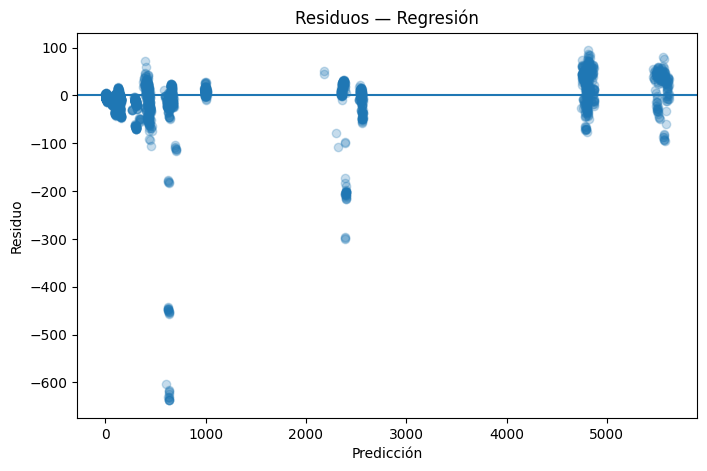

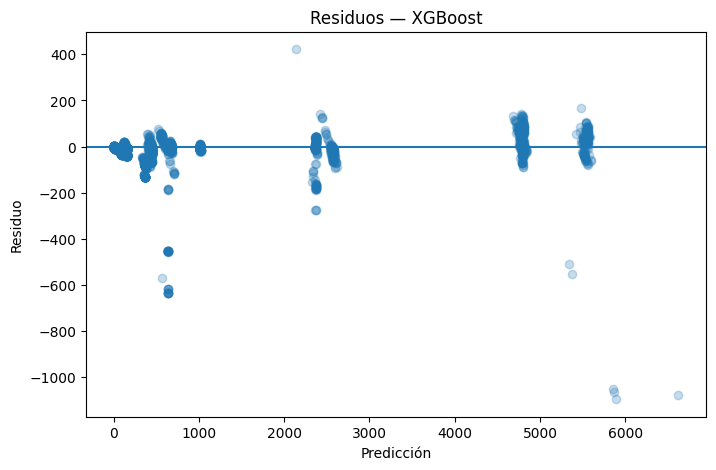

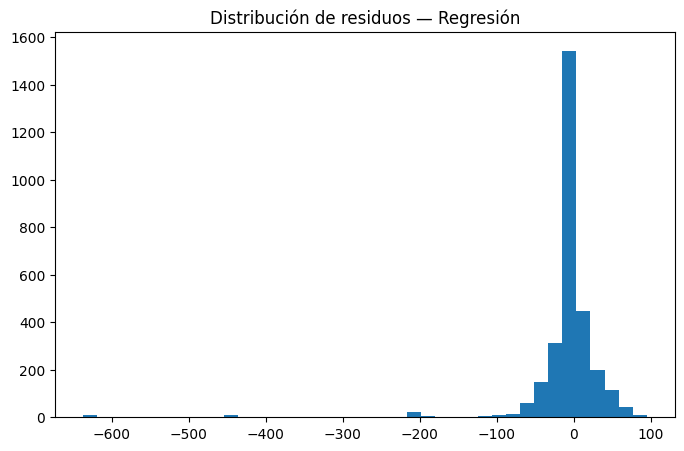

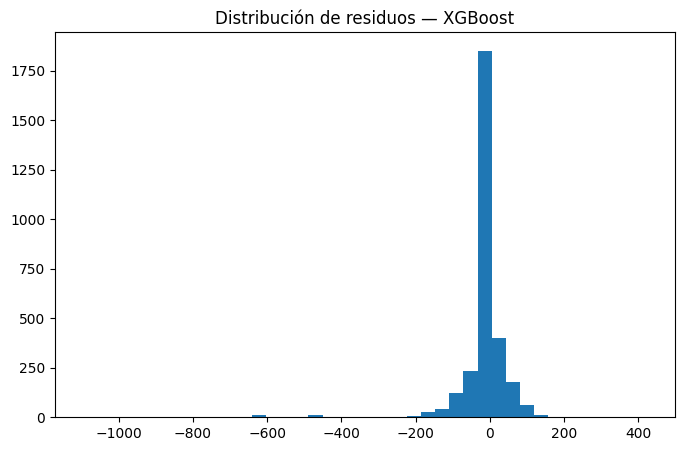

In [27]:

# Regresión
res_reg = y_test.values - pred_reg

plt.figure(figsize=(8,5))
plt.scatter(pred_reg, res_reg, alpha=.25)
plt.axhline(0)
plt.xlabel("Predicción")
plt.ylabel("Residuo")
plt.title("Residuos — Regresión")
plt.show()

# XGBoost
res_xgb = y_test.values - pred_xgb

plt.figure(figsize=(8,5))
plt.scatter(pred_xgb, res_xgb, alpha=.25)
plt.axhline(0)
plt.xlabel("Predicción")
plt.ylabel("Residuo")
plt.title("Residuos — XGBoost")
plt.show()

# Histograma comparativo por separado
plt.figure(figsize=(8,5))
plt.hist(res_reg, bins=40)
plt.title("Distribución de residuos — Regresión")
plt.show()

plt.figure(figsize=(8,5))
plt.hist(res_xgb, bins=40)
plt.title("Distribución de residuos — XGBoost")
plt.show()


                                     SARIMAX Results                                      
Dep. Variable:                     PoblacionPenal   No. Observations:                  731
Model:             SARIMAX(2, 1, 1)x(1, 0, [], 7)   Log Likelihood               -4773.129
Date:                            Mon, 21 Sep 2026   AIC                           9556.257
Time:                                    22:30:02   BIC                           9579.161
Sample:                                01-01-2024   HQIC                          9565.099
                                     - 12-31-2025                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0046      0.025     -0.181      0.856      -0.054       0.045
ar.L2         -0.0036      0.026   

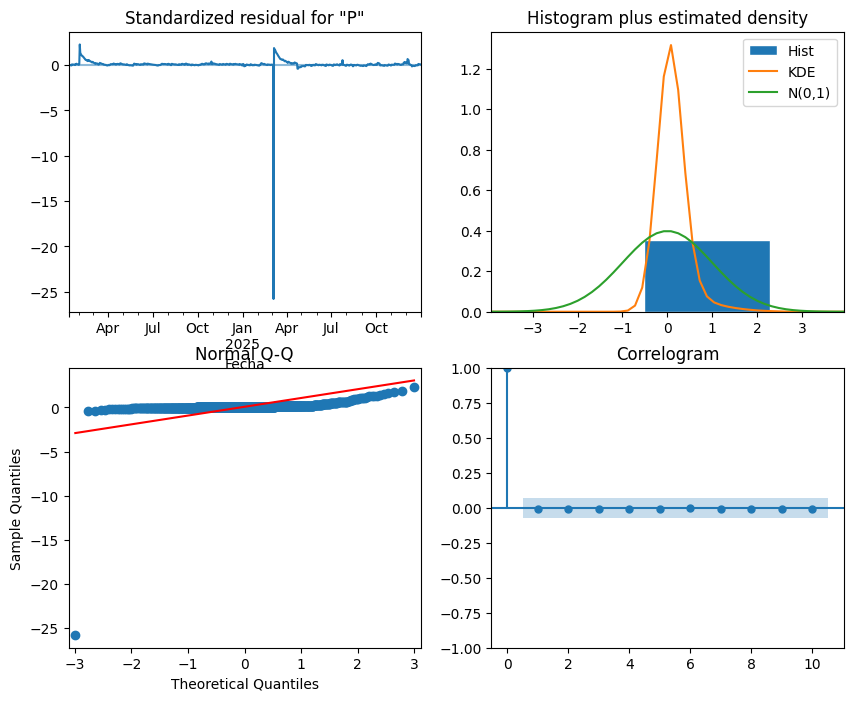

     lb_stat  lb_pvalue
7   0.164765   0.999987
14  0.294207   1.000000
21  0.373774   1.000000


In [28]:

# Diagnóstico del SARIMA para el centro de ejemplo usando la mejor especificación por AIC
if len(tabla_aic):
    mejor_order = eval(tabla_aic.iloc[0]["order"])
    mejor_seasonal = eval(tabla_aic.iloc[0]["seasonal_order"])

    fit_final = SARIMAX(
        serie_train,
        order=mejor_order,
        seasonal_order=mejor_seasonal,
        enforce_stationarity=False,
        enforce_invertibility=False
    ).fit(disp=False)

    print(fit_final.summary())
    fit_final.plot_diagnostics(figsize=(10,8))
    plt.show()

    residuos_sarima = fit_final.resid.dropna()

    print(
        acorr_ljungbox(
            residuos_sarima,
            lags=[7, 14, 21],
            return_df=True
        )
    )



# BLOQUE H — Importancia de variables en XGBoost


,Variable,Importancia
10,num__Capacidad,0.485990
44,cat__Provincia_Panamá,0.322261
11,num__Camas,0.103203
5,num__MediaMovil30,0.061259
4,num__MediaMovil7,0.021001
0,num__PoblacionPenal,0.001627
1,num__PoblacionLag1,0.001508
31,cat__Centro_Cárcel Pública De Deborah,0.000656
24,cat__Centro_Centro Penitenciario De Chiriquí,0.000646
22,cat__Centro_Centro Femenino Los Algarrobos,0.000554


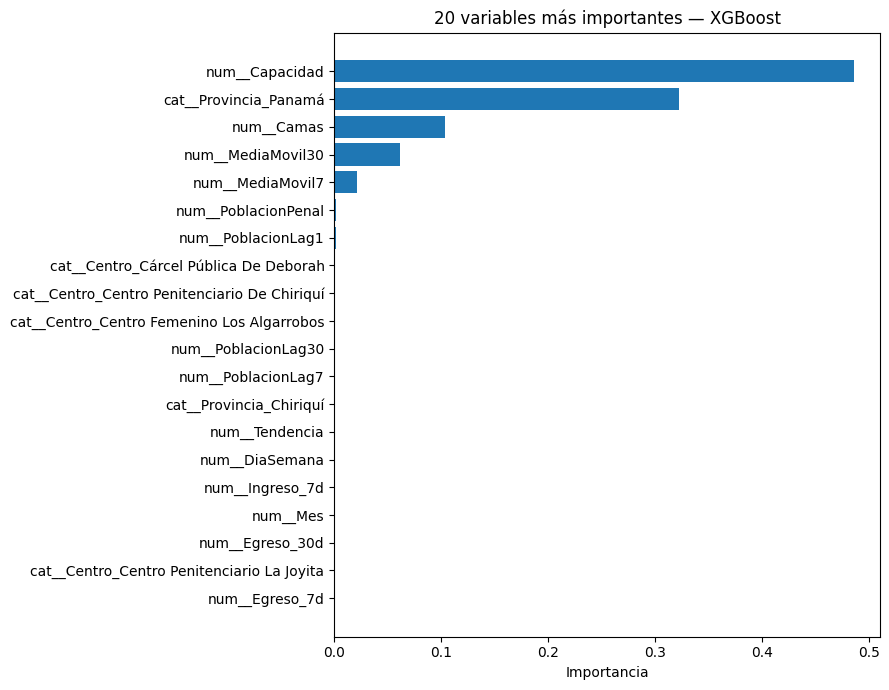

In [29]:

# Recuperar nombres de variables después del preprocesamiento
prep = modelo_xgb.named_steps["prep"]
modelo = modelo_xgb.named_steps["modelo"]

nombres = prep.get_feature_names_out()
importancias = modelo.feature_importances_

imp = (
    pd.DataFrame({"Variable": nombres, "Importancia": importancias})
      .sort_values("Importancia", ascending=False)
      .head(20)
)

display(imp)

plt.figure(figsize=(9,7))
plt.barh(imp["Variable"][::-1], imp["Importancia"][::-1])
plt.title("20 variables más importantes — XGBoost")
plt.xlabel("Importancia")
plt.tight_layout()
plt.show()



# Conclusión metodológica esperada

El proyecto debe responder tres preguntas diferentes:

1. **¿Qué ha ocurrido?**  
   Análisis descriptivo por mes, trimestre, año, provincia y centro.

2. **¿Qué variables explican la población futura?**  
   Regresión con contraste de hipótesis y errores estándar agrupados por centro.

3. **¿Qué modelo pronostica mejor?**  
   Comparación fuera de muestra de media móvil, regresión, SARIMA y XGBoost mediante MAE, RMSE, MAPE/WAPE y \(R^2\).

La elección final debe basarse en desempeño fuera de muestra, interpretabilidad y coherencia de los residuales; no únicamente en \(R^2\) o AIC.


# BLOQUE I — GRÁFICOS DE AJUSTE DE LOS MODELOS DE PRONÓSTICO

Además de las métricas globales, conviene visualizar la trayectoria real y pronosticada. Para hacer legible el gráfico, las predicciones del conjunto de prueba se agregan por fecha objetivo a nivel del sistema penitenciario.

> Las fechas 28–30/01/2026 fueron retiradas antes de construir las variables y el conjunto de evaluación. Por ello, sus desplazamientos a 30 días ya no generan caídas artificiales en los gráficos de ajuste.

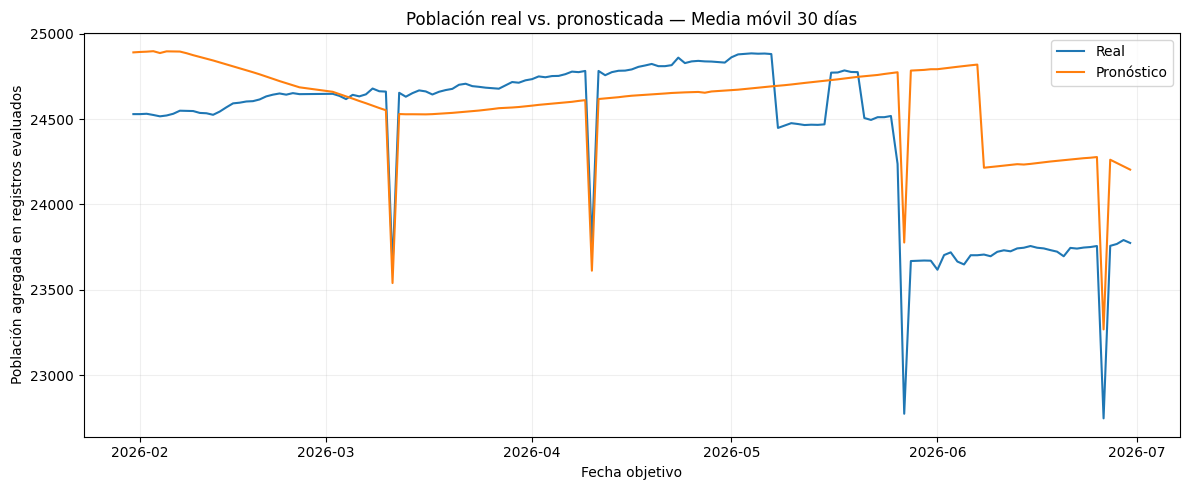

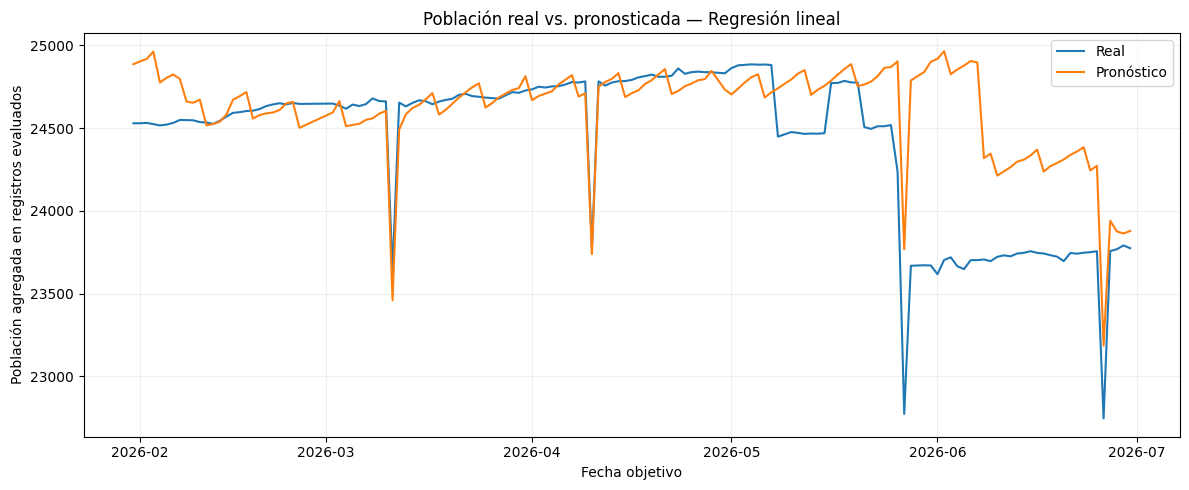

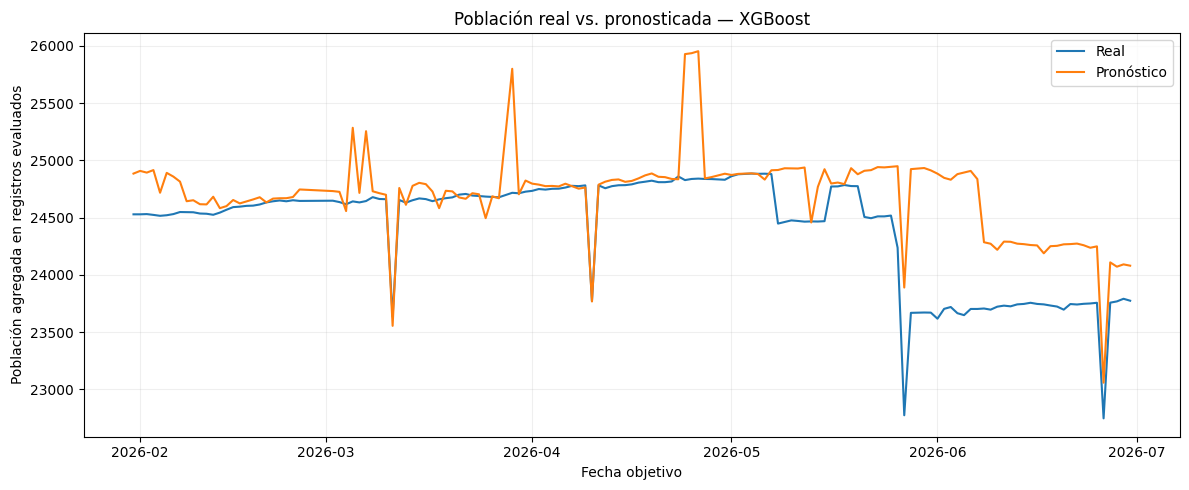

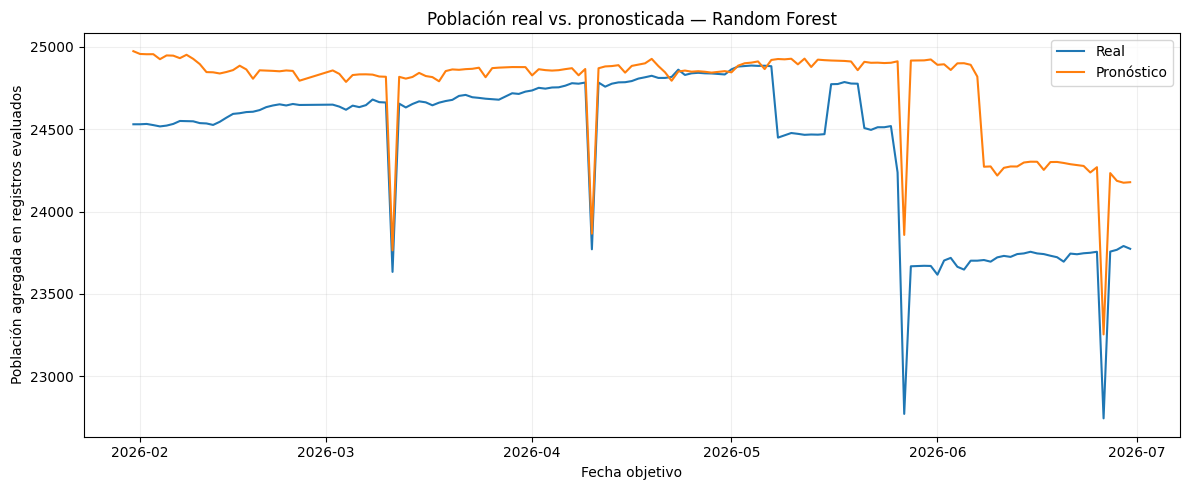

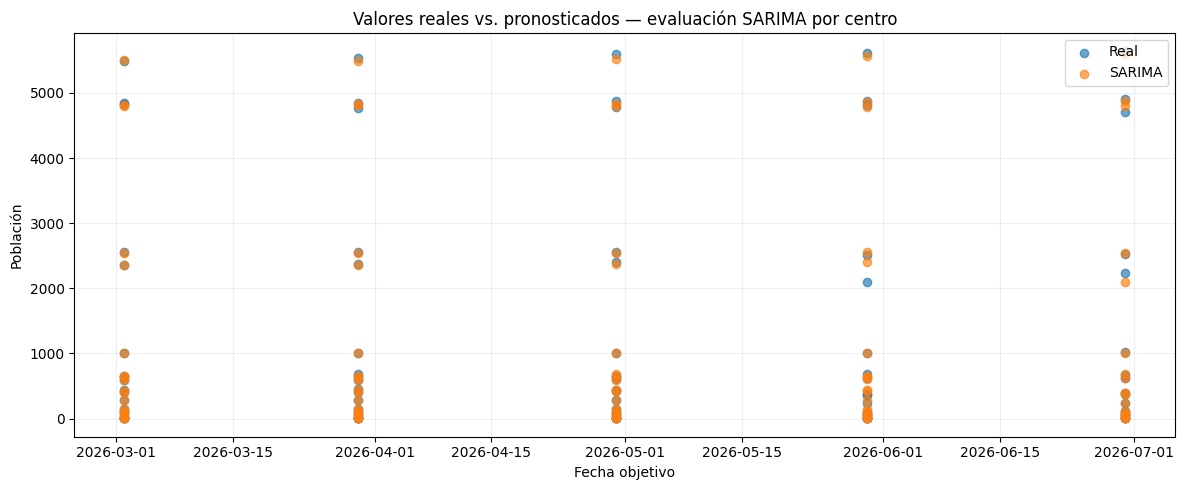

In [30]:
# Dataset de predicciones del conjunto de prueba
pred_panel = test[["FechaObjetivo"]].copy()
pred_panel["Real"] = y_test.values
pred_panel["MediaMovil"] = pred_ma
pred_panel["Regresion"] = pred_reg
pred_panel["XGBoost"] = pred_xgb
pred_panel["RandomForest"] = pred_rf

pred_sistema = (
    pred_panel.groupby("FechaObjetivo", as_index=False)
              .sum(numeric_only=True)
              .sort_values("FechaObjetivo")
)

for modelo_col, titulo in [
    ("MediaMovil", "Media móvil 30 días"),
    ("Regresion", "Regresión lineal"),
    ("XGBoost", "XGBoost"),
    ("RandomForest", "Random Forest")
]:
    plt.figure(figsize=(12,5))
    plt.plot(pred_sistema["FechaObjetivo"], pred_sistema["Real"], label="Real")
    plt.plot(pred_sistema["FechaObjetivo"], pred_sistema[modelo_col], label="Pronóstico")
    plt.title(f"Población real vs. pronosticada — {titulo}")
    plt.xlabel("Fecha objetivo")
    plt.ylabel("Población agregada en registros evaluados")
    plt.legend()
    plt.grid(alpha=.2)
    plt.tight_layout()
    plt.show()

# SARIMA: puntos reales vs pronosticados en los orígenes evaluados
if len(sarima_eval):
    sarima_plot = sarima_eval.sort_values("FechaObjetivo")
    plt.figure(figsize=(12,5))
    plt.scatter(sarima_plot["FechaObjetivo"], sarima_plot["Real"], alpha=.65, label="Real")
    plt.scatter(sarima_plot["FechaObjetivo"], sarima_plot["Pred_SARIMA"], alpha=.65, label="SARIMA")
    plt.title("Valores reales vs. pronosticados — evaluación SARIMA por centro")
    plt.xlabel("Fecha objetivo")
    plt.ylabel("Población")
    plt.legend()
    plt.grid(alpha=.2)
    plt.tight_layout()
    plt.show()

## I.1 Residuales a lo largo del tiempo

Un buen modelo no solo debe minimizar MAE o RMSE; los errores deberían oscilar alrededor de cero sin mostrar una estructura temporal persistente. Se presentan residuales agregados para facilitar su lectura.

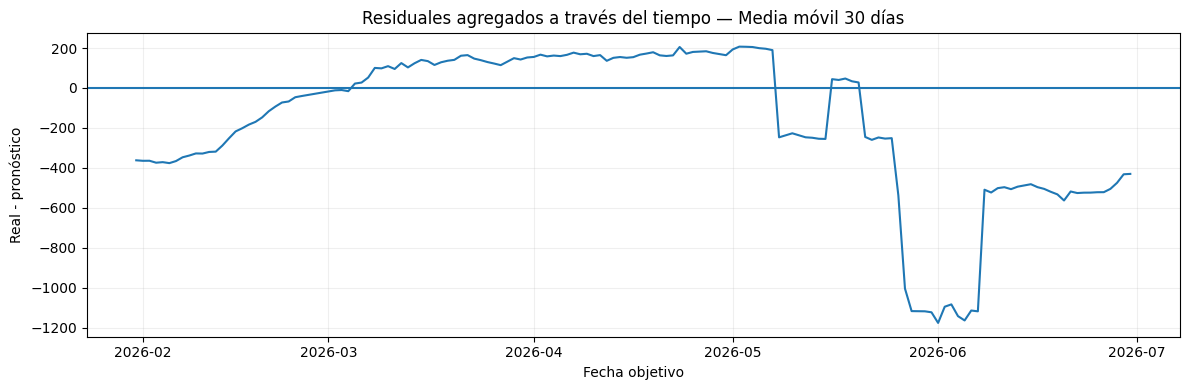

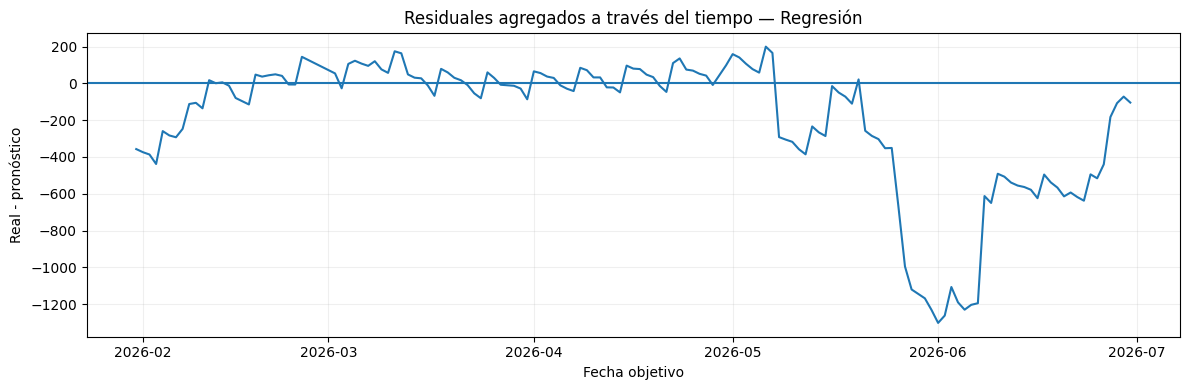

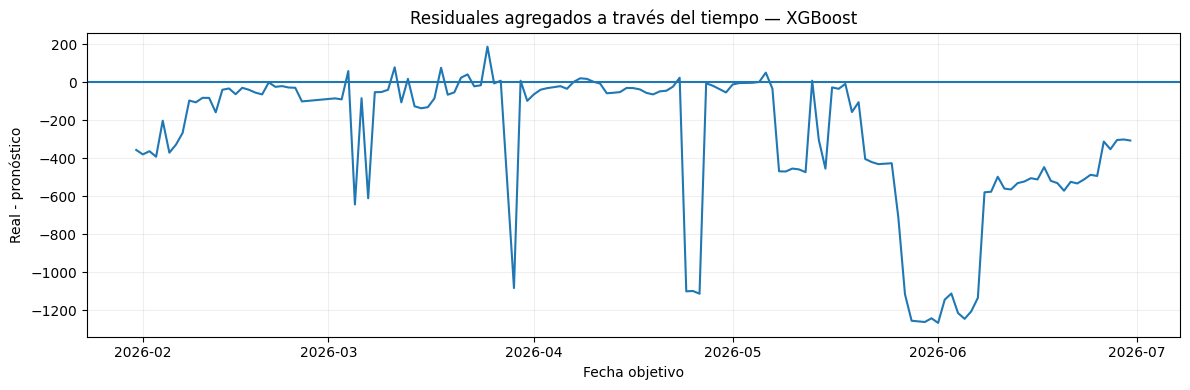

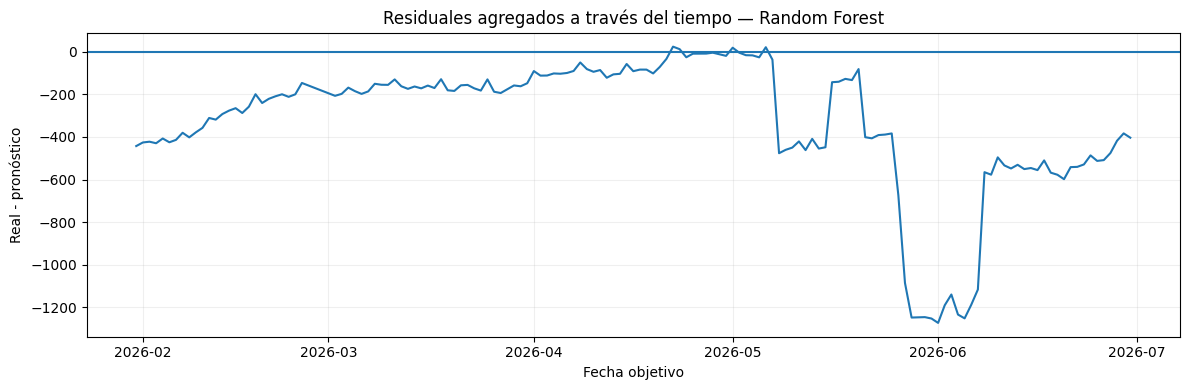

In [31]:
residuales_sistema = pred_sistema[["FechaObjetivo"]].copy()
for col in ["MediaMovil", "Regresion", "XGBoost", "RandomForest"]:
    residuales_sistema[col] = pred_sistema["Real"] - pred_sistema[col]

for col, titulo in [
    ("MediaMovil", "Media móvil 30 días"),
    ("Regresion", "Regresión"),
    ("XGBoost", "XGBoost"),
    ("RandomForest", "Random Forest")
]:
    plt.figure(figsize=(12,4))
    plt.plot(residuales_sistema["FechaObjetivo"], residuales_sistema[col])
    plt.axhline(0)
    plt.title(f"Residuales agregados a través del tiempo — {titulo}")
    plt.xlabel("Fecha objetivo")
    plt.ylabel("Real - pronóstico")
    plt.grid(alpha=.2)
    plt.tight_layout()
    plt.show()

# BLOQUE J — PRONÓSTICO MENSUAL DEL SISTEMA: JULIO–DICIEMBRE 2026

Para esta extensión se construyen tres series mensuales:

- **Población:** último corte de cada mes.
- **Ingresos:** suma mensual del sistema.
- **Egresos:** suma mensual del sistema.

Como solo existen 30 meses completos entre enero de 2024 y junio de 2026, se comparan modelos parsimoniosos: Naive, media móvil de 3 meses, tendencia lineal, Holt amortiguado y ARIMA(1,1,1). El modelo se selecciona por RMSE en una validación de seis meses, usando enero–junio de 2026 como período de prueba retrospectiva.

> Los agregados mensuales de enero de 2026 se calculan sin los registros del 28, 29 y 30 de enero, conforme a la regla de depuración solicitada.

In [32]:
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import Holt

# Base mensual única para proyecciones futuras
base_mensual = resumen_mensual[["Periodo", "Año", "Mes", "Poblacion", "Ingresos", "Egresos"]].copy()
base_mensual = base_mensual.sort_values("Periodo").reset_index(drop=True)

MODELOS_MENSUALES = ["Naive", "Media móvil 3", "Tendencia lineal", "Holt", "ARIMA(1,1,1)"]

def pronosticar_simple(y, h, modelo):
    y = np.asarray(y, dtype=float)
    if modelo == "Naive":
        return np.repeat(y[-1], h)
    if modelo == "Media móvil 3":
        return np.repeat(np.mean(y[-min(3, len(y)):]), h)
    if modelo == "Tendencia lineal":
        x = np.arange(len(y)).reshape(-1,1)
        m = LinearRegression().fit(x, y)
        return m.predict(np.arange(len(y), len(y)+h).reshape(-1,1))
    if modelo == "Holt":
        fit = Holt(y, damped_trend=True, initialization_method="estimated").fit(optimized=True)
        return np.asarray(fit.forecast(h))
    if modelo == "ARIMA(1,1,1)":
        return np.asarray(ARIMA(y, order=(1,1,1)).fit().forecast(h))
    raise ValueError(modelo)

def validar_modelos_mensuales(serie, h_test=6):
    y = np.asarray(serie, dtype=float)
    train_m, test_m = y[:-h_test], y[-h_test:]
    filas = []
    for modelo in MODELOS_MENSUALES:
        try:
            pred = pronosticar_simple(train_m, h_test, modelo)
            filas.append({
                "Modelo": modelo,
                "MAE": mean_absolute_error(test_m, pred),
                "RMSE": np.sqrt(mean_squared_error(test_m, pred))
            })
        except Exception:
            pass
    return pd.DataFrame(filas).sort_values("RMSE").reset_index(drop=True)

validaciones = {}
pronosticos_2026 = pd.DataFrame({
    "Fecha": pd.date_range("2026-07-31", "2026-12-31", freq="ME")
})

for variable in ["Poblacion", "Ingresos", "Egresos"]:
    tabla_val = validar_modelos_mensuales(base_mensual[variable], h_test=6)
    validaciones[variable] = tabla_val
    mejor_modelo = tabla_val.iloc[0]["Modelo"]
    rmse_val = tabla_val.iloc[0]["RMSE"]
    pred = pronosticar_simple(base_mensual[variable], 6, mejor_modelo)
    pred = np.maximum(pred, 0)

    pronosticos_2026[variable] = pred
    pronosticos_2026[f"Modelo_{variable}"] = mejor_modelo
    pronosticos_2026[f"LI95_{variable}"] = np.maximum(pred - 1.96*rmse_val, 0)
    pronosticos_2026[f"LS95_{variable}"] = pred + 1.96*rmse_val

print("Validación retrospectiva — Población")
display(validaciones["Poblacion"])
print("Validación retrospectiva — Ingresos")
display(validaciones["Ingresos"])
print("Validación retrospectiva — Egresos")
display(validaciones["Egresos"])

print("Pronóstico mensual julio–diciembre de 2026")
display(pronosticos_2026.round(1))

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/statespace/mlemodel.py:679: EstimationWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  start_params = self.start_params
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/statespace/mlemodel.py:679: EstimationWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  start_params = self.start_params


Validación retrospectiva — Población


,Modelo,MAE,RMSE
0,Media móvil 3,277.055556,359.804191
1,Naive,397.166667,466.656369
2,Holt,444.103278,515.305357
3,Tendencia lineal,493.969565,575.349854
4,"ARIMA(1,1,1)",582.328723,655.889488


Validación retrospectiva — Ingresos


,Modelo,MAE,RMSE
0,Holt,151.222067,172.745723
1,Tendencia lineal,159.919010,183.174601
2,Media móvil 3,151.000000,185.153090
3,"ARIMA(1,1,1)",151.659268,189.840001
4,Naive,155.666667,198.628632


Validación retrospectiva — Egresos


,Modelo,MAE,RMSE
0,Naive,292.833333,420.773296
1,Media móvil 3,289.166667,437.546886
2,"ARIMA(1,1,1)",289.730327,438.870827
3,Tendencia lineal,291.233261,452.209266
4,Holt,293.967687,455.420419


Pronóstico mensual julio–diciembre de 2026


,Fecha,Poblacion,Modelo_Poblacion,LI95_Poblacion,LS95_Poblacion,Ingresos,Modelo_Ingresos,LI95_Ingresos,LS95_Ingresos,Egresos,Modelo_Egresos,LI95_Egresos,LS95_Egresos
0,2026-07-31,24418.0,Media móvil 3,23712.8,25123.2,858.9,Holt,520.3,1197.5,825.0,Naive,0.3,1649.7
1,2026-08-31,24418.0,Media móvil 3,23712.8,25123.2,858.8,Holt,520.2,1197.4,825.0,Naive,0.3,1649.7
2,2026-09-30,24418.0,Media móvil 3,23712.8,25123.2,858.7,Holt,520.1,1197.3,825.0,Naive,0.3,1649.7
3,2026-10-31,24418.0,Media móvil 3,23712.8,25123.2,858.7,Holt,520.1,1197.2,825.0,Naive,0.3,1649.7
4,2026-11-30,24418.0,Media móvil 3,23712.8,25123.2,858.6,Holt,520.0,1197.2,825.0,Naive,0.3,1649.7
5,2026-12-31,24418.0,Media móvil 3,23712.8,25123.2,858.6,Holt,520.0,1197.2,825.0,Naive,0.3,1649.7


## J.1 Escenario de población basado en el balance de ingresos y egresos

En la serie histórica del sistema, la variación mensual de población presenta una correspondencia muy alta con el saldo mensual `Ingresos − Egresos`. Por ello se construye un segundo escenario de población acumulando el saldo pronosticado desde el último corte observado de junio de 2026.

Este escenario no reemplaza el pronóstico directo: ambos se muestran para evaluar consistencia.

Correlación histórica ΔPoblación vs. Ingresos-Egresos: 0.9988


,Fecha,Ingresos,Egresos,SaldoPronosticado,Poblacion,Poblacion_por_balance
0,2026-07-31,858.9,825.0,33.9,24418.0,24326.9
1,2026-08-31,858.8,825.0,33.8,24418.0,24360.7
2,2026-09-30,858.7,825.0,33.7,24418.0,24394.4
3,2026-10-31,858.7,825.0,33.7,24418.0,24428.0
4,2026-11-30,858.6,825.0,33.6,24418.0,24461.7
5,2026-12-31,858.6,825.0,33.6,24418.0,24495.2


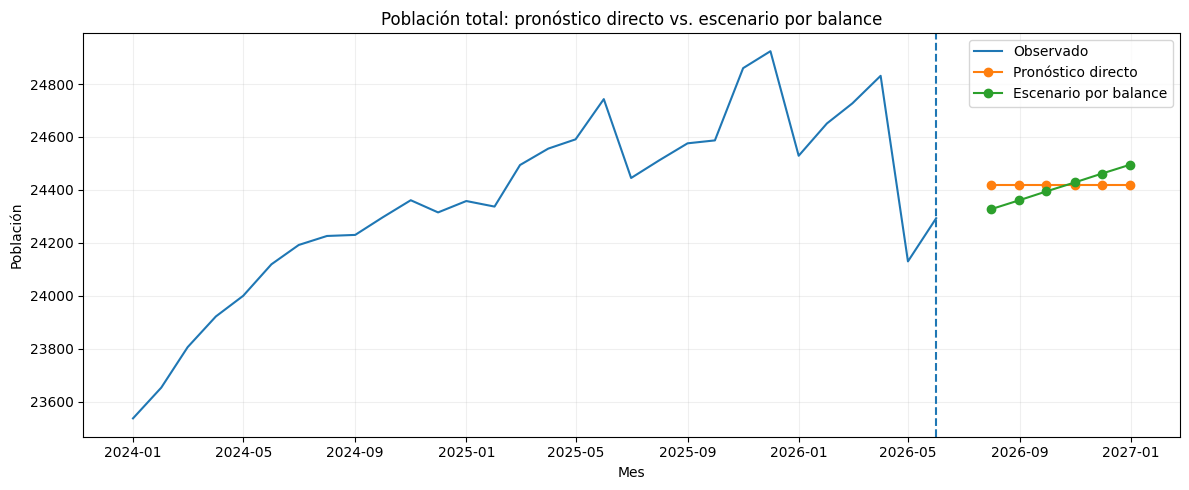

In [33]:
# Relación histórica entre variación poblacional y saldo
balance_hist = base_mensual[["Periodo", "Poblacion", "Ingresos", "Egresos"]].copy()
balance_hist["DeltaPoblacion"] = balance_hist["Poblacion"].diff()
balance_hist["Saldo"] = balance_hist["Ingresos"] - balance_hist["Egresos"]
cor_balance = balance_hist[["DeltaPoblacion", "Saldo"]].corr().iloc[0,1]
print(f"Correlación histórica ΔPoblación vs. Ingresos-Egresos: {cor_balance:.4f}")

pronosticos_2026["SaldoPronosticado"] = pronosticos_2026["Ingresos"] - pronosticos_2026["Egresos"]
ultimo_p = base_mensual["Poblacion"].iloc[-1]
pronosticos_2026["Poblacion_por_balance"] = ultimo_p + pronosticos_2026["SaldoPronosticado"].cumsum()

display(pronosticos_2026[[
    "Fecha", "Ingresos", "Egresos", "SaldoPronosticado",
    "Poblacion", "Poblacion_por_balance"
]].round(1))

plt.figure(figsize=(12,5))
plt.plot(base_mensual["Periodo"], base_mensual["Poblacion"], label="Observado")
plt.plot(pronosticos_2026["Fecha"], pronosticos_2026["Poblacion"], marker="o", label="Pronóstico directo")
plt.plot(pronosticos_2026["Fecha"], pronosticos_2026["Poblacion_por_balance"], marker="o", label="Escenario por balance")
plt.axvline(base_mensual["Periodo"].max(), linestyle="--")
plt.title("Población total: pronóstico directo vs. escenario por balance")
plt.xlabel("Mes"); plt.ylabel("Población")
plt.legend(); plt.grid(alpha=.2); plt.tight_layout(); plt.show()

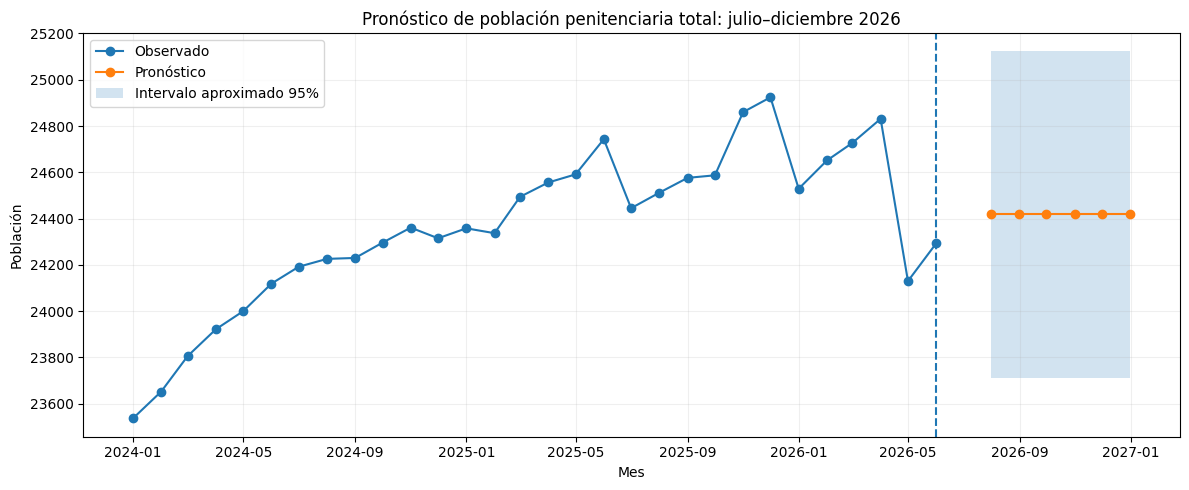

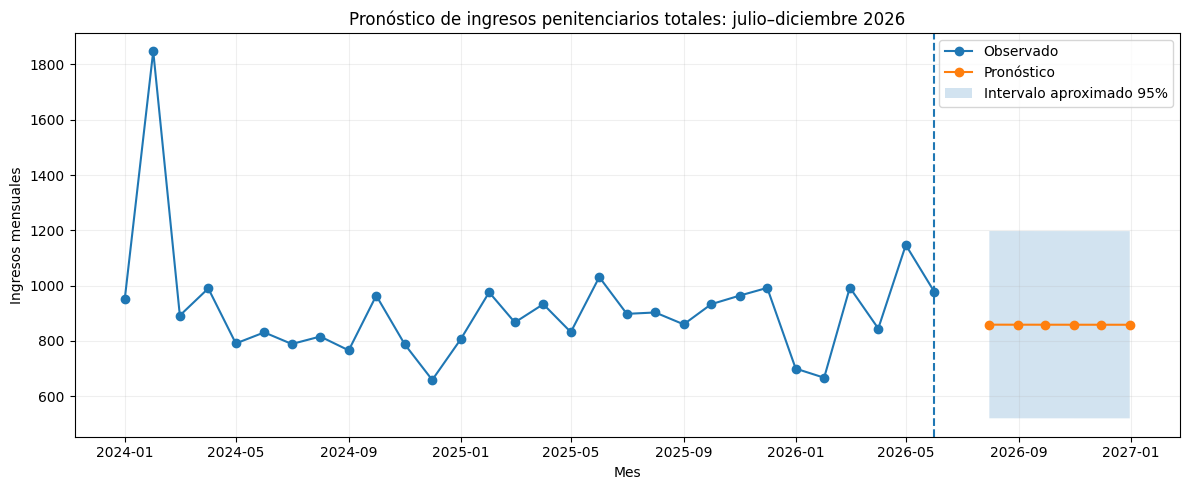

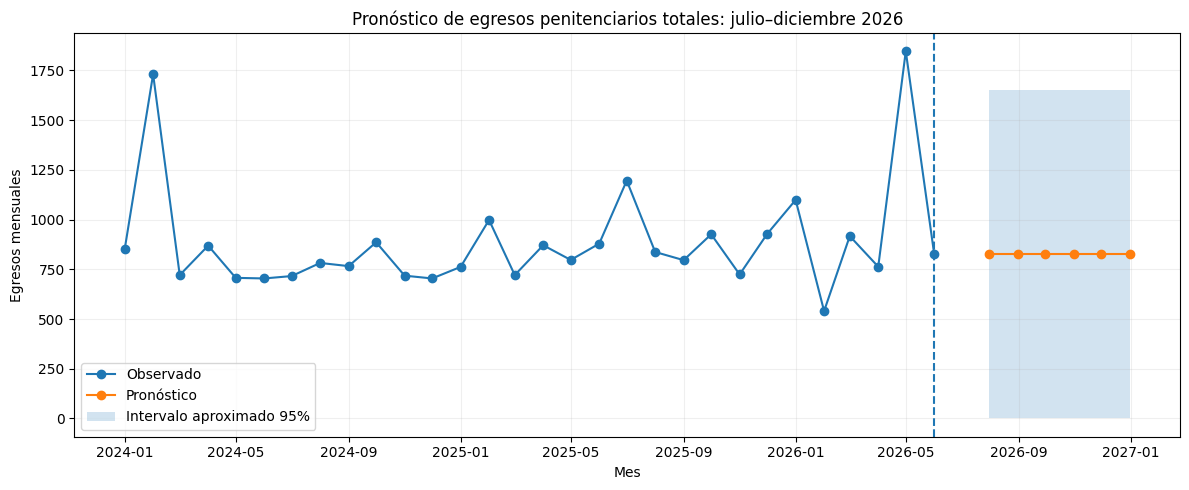

In [34]:
# Gráficos históricos + pronóstico 2026
for variable, titulo, eje_y in [
    ("Poblacion", "Pronóstico de población penitenciaria total", "Población"),
    ("Ingresos", "Pronóstico de ingresos penitenciarios totales", "Ingresos mensuales"),
    ("Egresos", "Pronóstico de egresos penitenciarios totales", "Egresos mensuales")
]:
    plt.figure(figsize=(12,5))
    plt.plot(base_mensual["Periodo"], base_mensual[variable], marker="o", label="Observado")
    plt.plot(pronosticos_2026["Fecha"], pronosticos_2026[variable], marker="o", label="Pronóstico")
    plt.fill_between(
        pronosticos_2026["Fecha"],
        pronosticos_2026[f"LI95_{variable}"],
        pronosticos_2026[f"LS95_{variable}"],
        alpha=.2,
        label="Intervalo aproximado 95%"
    )
    plt.axvline(base_mensual["Periodo"].max(), linestyle="--")
    plt.title(f"{titulo}: julio–diciembre 2026")
    plt.xlabel("Mes")
    plt.ylabel(eje_y)
    plt.legend()
    plt.grid(alpha=.2)
    plt.tight_layout()
    plt.show()

> **Nota metodológica:** el intervalo mostrado es aproximado y se construye a partir del RMSE obtenido en la validación retrospectiva de seis meses. Con solo 30 observaciones mensuales, estas proyecciones deben interpretarse como escenarios analíticos y no como valores determinísticos.

# BLOQUE K — CASO DE ESTUDIO: CENTRO PENITENCIARIO LA NUEVA JOYA

Se analiza de forma separada **Centro Penitenciario La Nueva Joya** para ilustrar cómo el enfoque puede apoyar planificación operativa por establecimiento. Se proyectan población al cierre mensual, ingresos mensuales y egresos mensuales desde julio de 2026 hasta junio de 2027.

In [35]:
CENTRO_CASO = "Centro Penitenciario La Nueva Joya"

nueva_joya = df[df["Centro"] == CENTRO_CASO].copy()

# Stock mensual de población
nj_stock = (
    nueva_joya.sort_values("Fecha")
              .groupby(["Año", "Mes"], as_index=False)
              .tail(1)[["Año", "Mes", "PoblacionPenal"]]
)

# Flujos mensuales
nj_flujos = (
    nueva_joya.groupby(["Año", "Mes"], as_index=False)
              .agg(Ingresos=("Ingreso", "sum"), Egresos=("Egreso", "sum"))
)

nj_mensual = nj_stock.merge(nj_flujos, on=["Año", "Mes"], how="inner")
nj_mensual["Periodo"] = pd.to_datetime(
    dict(year=nj_mensual["Año"], month=nj_mensual["Mes"], day=1)
) + pd.offsets.MonthEnd(0)
nj_mensual = nj_mensual.sort_values("Periodo").reset_index(drop=True)

# Validar y proyectar 12 meses
pron_nj = pd.DataFrame({
    "Fecha": pd.date_range("2026-07-31", "2027-06-30", freq="ME")
})

validacion_nj = {}
for variable in ["PoblacionPenal", "Ingresos", "Egresos"]:
    tabla_val = validar_modelos_mensuales(nj_mensual[variable], h_test=6)
    validacion_nj[variable] = tabla_val
    mejor = tabla_val.iloc[0]["Modelo"]
    rmse_val = tabla_val.iloc[0]["RMSE"]
    pred = pronosticar_simple(nj_mensual[variable], 12, mejor)
    pred = np.maximum(pred, 0)

    pron_nj[variable] = pred
    pron_nj[f"Modelo_{variable}"] = mejor
    pron_nj[f"LI95_{variable}"] = np.maximum(pred - 1.96*rmse_val, 0)
    pron_nj[f"LS95_{variable}"] = pred + 1.96*rmse_val

print("La Nueva Joya — validación de población")
display(validacion_nj["PoblacionPenal"])
print("La Nueva Joya — validación de ingresos")
display(validacion_nj["Ingresos"])
print("La Nueva Joya — validación de egresos")
display(validacion_nj["Egresos"])

print("La Nueva Joya — proyección julio 2026 a junio 2027")
display(pron_nj.round(1))

print("Ingresos acumulados pronosticados Jul-2026 a Jun-2027:", round(pron_nj["Ingresos"].sum()))
print("Egresos acumulados pronosticados Jul-2026 a Jun-2027:", round(pron_nj["Egresos"].sum()))

La Nueva Joya — validación de población


/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/statespace/mlemodel.py:679: EstimationWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  start_params = self.start_params


,Modelo,MAE,RMSE
0,Naive,56.166667,60.400055
1,Media móvil 3,60.055556,69.671850
2,"ARIMA(1,1,1)",55.980635,70.708814
3,Holt,79.831814,85.675477
4,Tendencia lineal,114.144203,138.541952


La Nueva Joya — validación de ingresos


,Modelo,MAE,RMSE
0,Media móvil 3,33.333333,40.524341
1,Naive,33.333333,41.649330
2,"ARIMA(1,1,1)",34.585889,43.509786
3,Holt,52.633374,60.036342
4,Tendencia lineal,57.375072,65.720791


La Nueva Joya — validación de egresos


,Modelo,MAE,RMSE
0,"ARIMA(1,1,1)",46.541585,54.404537
1,Media móvil 3,47.055556,54.441100
2,Holt,47.563794,54.953256
3,Tendencia lineal,48.967826,56.314196
4,Naive,52.166667,61.203213


La Nueva Joya — proyección julio 2026 a junio 2027


,Fecha,PoblacionPenal,Modelo_PoblacionPenal,LI95_PoblacionPenal,LS95_PoblacionPenal,Ingresos,Modelo_Ingresos,LI95_Ingresos,LS95_Ingresos,Egresos,Modelo_Egresos,LI95_Egresos,LS95_Egresos
0,2026-07-31,5641.0,Naive,5522.6,5759.4,157.7,Media móvil 3,78.2,237.1,107.5,"ARIMA(1,1,1)",0.9,214.2
1,2026-08-31,5641.0,Naive,5522.6,5759.4,157.7,Media móvil 3,78.2,237.1,114.3,"ARIMA(1,1,1)",7.7,220.9
2,2026-09-30,5641.0,Naive,5522.6,5759.4,157.7,Media móvil 3,78.2,237.1,111.8,"ARIMA(1,1,1)",5.2,218.5
3,2026-10-31,5641.0,Naive,5522.6,5759.4,157.7,Media móvil 3,78.2,237.1,112.7,"ARIMA(1,1,1)",6.1,219.4
4,2026-11-30,5641.0,Naive,5522.6,5759.4,157.7,Media móvil 3,78.2,237.1,112.4,"ARIMA(1,1,1)",5.8,219.0
5,2026-12-31,5641.0,Naive,5522.6,5759.4,157.7,Media móvil 3,78.2,237.1,112.5,"ARIMA(1,1,1)",5.9,219.2
6,2027-01-31,5641.0,Naive,5522.6,5759.4,157.7,Media móvil 3,78.2,237.1,112.5,"ARIMA(1,1,1)",5.8,219.1
7,2027-02-28,5641.0,Naive,5522.6,5759.4,157.7,Media móvil 3,78.2,237.1,112.5,"ARIMA(1,1,1)",5.9,219.1
8,2027-03-31,5641.0,Naive,5522.6,5759.4,157.7,Media móvil 3,78.2,237.1,112.5,"ARIMA(1,1,1)",5.9,219.1
9,2027-04-30,5641.0,Naive,5522.6,5759.4,157.7,Media móvil 3,78.2,237.1,112.5,"ARIMA(1,1,1)",5.9,219.1


Ingresos acumulados pronosticados Jul-2026 a Jun-2027: 1892
Egresos acumulados pronosticados Jul-2026 a Jun-2027: 1346


## K.1 Proyección coherente de población mediante el balance de flujos

En La Nueva Joya, la variación mensual observada de población y el saldo `Ingresos − Egresos` tienen una asociación casi perfecta en la historia disponible. Por ello se incorpora una proyección acumulativa adicional:

\[
P_{t+1}=P_t+Ingresos_{t+1}-Egresos_{t+1}
\]

Este escenario responde directamente a la pregunta operativa de cuántas personas podrían entrar, salir y cuál sería el efecto neto sobre la población del centro.

Correlación histórica ΔPoblación vs. saldo en La Nueva Joya: 0.9976
Diferencia no explicada promedio: 0.24 personas/mes
Proyección operativa — La Nueva Joya


,Fecha,Ingresos,Egresos,SaldoPronosticado,PoblacionPenal,Poblacion_por_balance
0,2026-07-31,157.7,107.5,50.1,5641.0,5691.1
1,2026-08-31,157.7,114.3,43.4,5641.0,5734.5
2,2026-09-30,157.7,111.8,45.8,5641.0,5780.3
3,2026-10-31,157.7,112.7,44.9,5641.0,5825.3
4,2026-11-30,157.7,112.4,45.3,5641.0,5870.6
5,2026-12-31,157.7,112.5,45.1,5641.0,5915.7
6,2027-01-31,157.7,112.5,45.2,5641.0,5960.9
7,2027-02-28,157.7,112.5,45.2,5641.0,6006.1
8,2027-03-31,157.7,112.5,45.2,5641.0,6051.2
9,2027-04-30,157.7,112.5,45.2,5641.0,6096.4


Saldo neto acumulado Jul-2026 a Jun-2027: 546
Población por balance estimada a Jun-2027: 6187


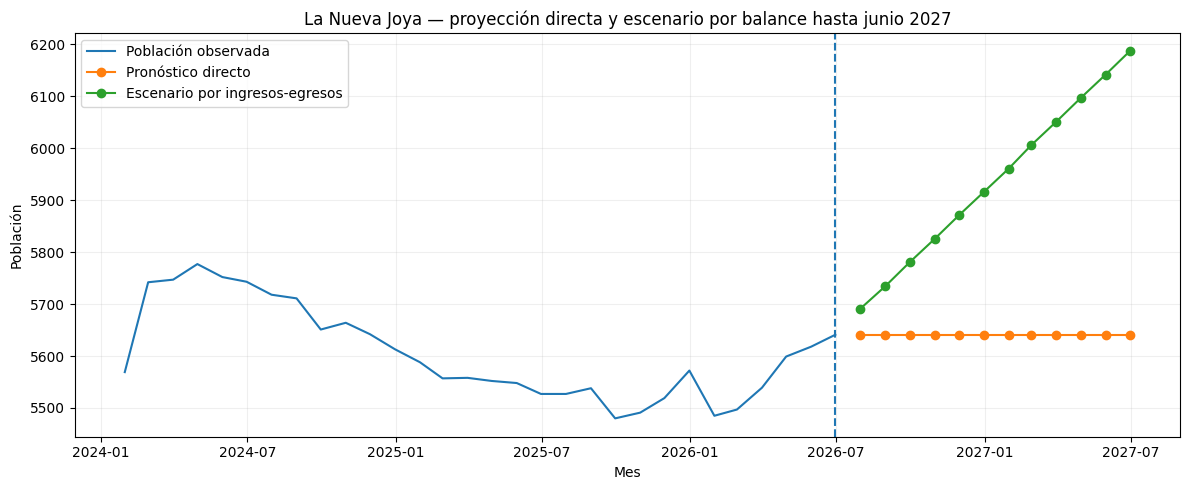

In [36]:
# Evidencia histórica de coherencia de balance en La Nueva Joya
nj_balance_hist = nj_mensual[["Periodo", "PoblacionPenal", "Ingresos", "Egresos"]].copy()
nj_balance_hist["DeltaPoblacion"] = nj_balance_hist["PoblacionPenal"].diff()
nj_balance_hist["Saldo"] = nj_balance_hist["Ingresos"] - nj_balance_hist["Egresos"]
nj_balance_hist["DiferenciaNoExplicada"] = nj_balance_hist["DeltaPoblacion"] - nj_balance_hist["Saldo"]

corr_nj = nj_balance_hist[["DeltaPoblacion", "Saldo"]].corr().iloc[0,1]
print(f"Correlación histórica ΔPoblación vs. saldo en La Nueva Joya: {corr_nj:.4f}")
print(f"Diferencia no explicada promedio: {nj_balance_hist['DiferenciaNoExplicada'].mean():.2f} personas/mes")

pron_nj["SaldoPronosticado"] = pron_nj["Ingresos"] - pron_nj["Egresos"]
ultima_pob_nj = nj_mensual["PoblacionPenal"].iloc[-1]
pron_nj["Poblacion_por_balance"] = ultima_pob_nj + pron_nj["SaldoPronosticado"].cumsum()

print("Proyección operativa — La Nueva Joya")
display(pron_nj[[
    "Fecha", "Ingresos", "Egresos", "SaldoPronosticado",
    "PoblacionPenal", "Poblacion_por_balance"
]].round(1))

print("Saldo neto acumulado Jul-2026 a Jun-2027:", round(pron_nj["SaldoPronosticado"].sum()))
print("Población por balance estimada a Jun-2027:", round(pron_nj["Poblacion_por_balance"].iloc[-1]))

plt.figure(figsize=(12,5))
plt.plot(nj_mensual["Periodo"], nj_mensual["PoblacionPenal"], label="Población observada")
plt.plot(pron_nj["Fecha"], pron_nj["PoblacionPenal"], marker="o", label="Pronóstico directo")
plt.plot(pron_nj["Fecha"], pron_nj["Poblacion_por_balance"], marker="o", label="Escenario por ingresos-egresos")
plt.axvline(nj_mensual["Periodo"].max(), linestyle="--")
plt.title("La Nueva Joya — proyección directa y escenario por balance hasta junio 2027")
plt.xlabel("Mes"); plt.ylabel("Población")
plt.legend(); plt.grid(alpha=.2); plt.tight_layout(); plt.show()

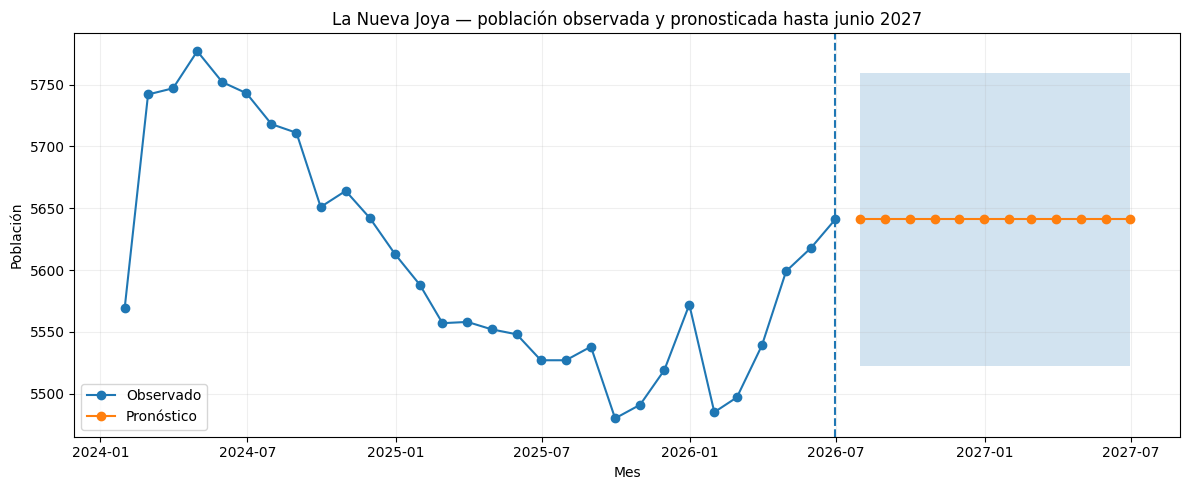

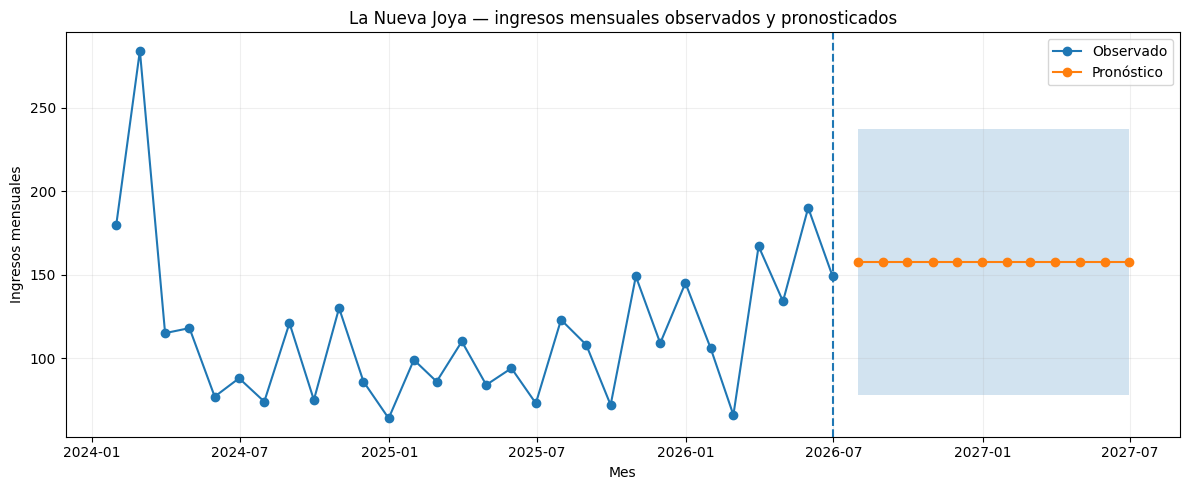

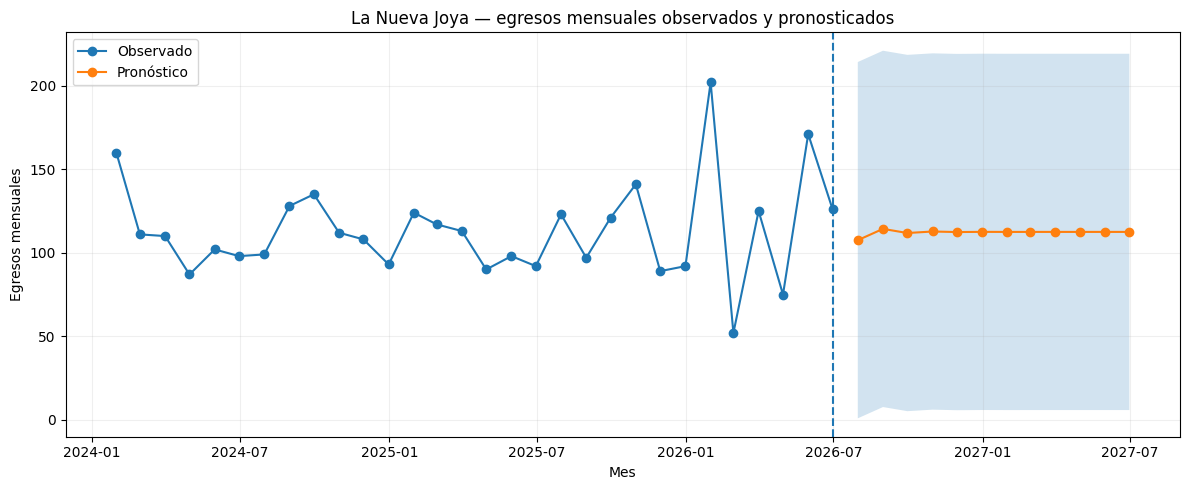

In [37]:
# Población — La Nueva Joya
plt.figure(figsize=(12,5))
plt.plot(nj_mensual["Periodo"], nj_mensual["PoblacionPenal"], marker="o", label="Observado")
plt.plot(pron_nj["Fecha"], pron_nj["PoblacionPenal"], marker="o", label="Pronóstico")
plt.fill_between(pron_nj["Fecha"], pron_nj["LI95_PoblacionPenal"], pron_nj["LS95_PoblacionPenal"], alpha=.2)
plt.axvline(nj_mensual["Periodo"].max(), linestyle="--")
plt.title("La Nueva Joya — población observada y pronosticada hasta junio 2027")
plt.xlabel("Mes")
plt.ylabel("Población")
plt.legend(); plt.grid(alpha=.2); plt.tight_layout(); plt.show()

# Ingresos — La Nueva Joya
plt.figure(figsize=(12,5))
plt.plot(nj_mensual["Periodo"], nj_mensual["Ingresos"], marker="o", label="Observado")
plt.plot(pron_nj["Fecha"], pron_nj["Ingresos"], marker="o", label="Pronóstico")
plt.fill_between(pron_nj["Fecha"], pron_nj["LI95_Ingresos"], pron_nj["LS95_Ingresos"], alpha=.2)
plt.axvline(nj_mensual["Periodo"].max(), linestyle="--")
plt.title("La Nueva Joya — ingresos mensuales observados y pronosticados")
plt.xlabel("Mes"); plt.ylabel("Ingresos mensuales")
plt.legend(); plt.grid(alpha=.2); plt.tight_layout(); plt.show()

# Egresos — La Nueva Joya
plt.figure(figsize=(12,5))
plt.plot(nj_mensual["Periodo"], nj_mensual["Egresos"], marker="o", label="Observado")
plt.plot(pron_nj["Fecha"], pron_nj["Egresos"], marker="o", label="Pronóstico")
plt.fill_between(pron_nj["Fecha"], pron_nj["LI95_Egresos"], pron_nj["LS95_Egresos"], alpha=.2)
plt.axvline(nj_mensual["Periodo"].max(), linestyle="--")
plt.title("La Nueva Joya — egresos mensuales observados y pronosticados")
plt.xlabel("Mes"); plt.ylabel("Egresos mensuales")
plt.legend(); plt.grid(alpha=.2); plt.tight_layout(); plt.show()

## Interpretación del caso La Nueva Joya

La proyección a doce meses es útil para planificación de capacidad, pero debe interpretarse con cautela. El modelo se selecciona por desempeño retrospectivo y no incorpora decisiones judiciales, traslados extraordinarios, aperturas/cierres de espacios, cambios normativos ni eventos operativos futuros que no estén contenidos en la serie histórica. Por ello, es recomendable actualizar el pronóstico mensualmente a medida que se incorporen nuevos datos.